# Product Recommendation System - Complete Workflow

## Structure
1. Data Loading & Preprocessing (single source of truth)
2. Exploratory Data Analysis (EDA)
3. Visualizations
4. Feature Engineering
5. Clustering Models
6. Model Evaluation
7. Recommendation Engine

This notebook merges the EDA and Modelling notebooks while avoiding duplicate dataset loading and cleaning steps.


#  EDA and Visualization — Product Recommendation System

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')          
pd.set_option('display.max_columns', None) # Show all columns in output

## 2. Load Dataset

In [2]:
# Load the ratings CSV file
# header=None → because the file has no column header row
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\ratings.csv", header=None)
df.head()

,0,1,2,3
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [3]:
# Assign proper column names to the dataset
df.columns = ['userId', 'productId', 'Rating', 'timestamp']
df.head()

,userId,productId,Rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [4]:
# Drop 'timestamp' — not needed for recommendation system
df = df.drop('timestamp', axis=1)
df.head()

,userId,productId,Rating
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


## 3. Basic Dataset Information

In [5]:
# Check total number of rows and columns
df.shape

(7824482, 3)

In [6]:
# Get dataset info: column types, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     object 
 1   productId  object 
 2   Rating     float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


In [7]:
# Statistical summary: mean, std, min, max, quartiles
df.describe()

,Rating
count,7.824482e+06
mean,4.012337e+00
std,1.380910e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


In [8]:
# Check data types of each column
df.dtypes

userId        object
productId     object
Rating       float64
dtype: object

## 4. Null Values & Duplicate Check

In [9]:
# Check for missing/null values in each column
df.isnull().sum()

userId       0
productId    0
Rating       0
dtype: int64

In [10]:
# Check for duplicate 
df.duplicated().sum()

np.int64(0)

## 5. Unique Users & Products

In [11]:
# Count how many unique users are in the dataset
print("Unique Users   :", df['userId'].nunique())

# Count how many unique products are in the dataset
print("Unique Products:", df['productId'].nunique())

# Total ratings recorded
print("Total Ratings  :", df.shape[0])

Unique Users   : 4201696
Unique Products: 476002
Total Ratings  : 7824482


## 6. Rating Distribution

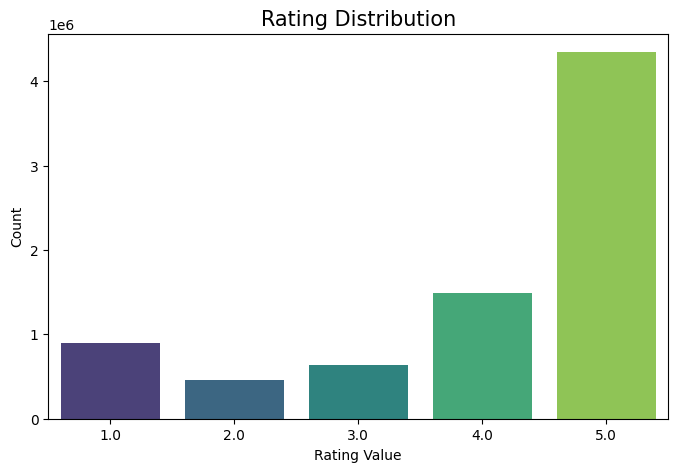

In [12]:
# BAR CHART — How many times each rating value appears
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Rating',
    data=df,
    palette='viridis'
)
plt.title("Rating Distribution", fontsize=15)
plt.xlabel("Rating Value")
plt.ylabel("Count")
plt.show()

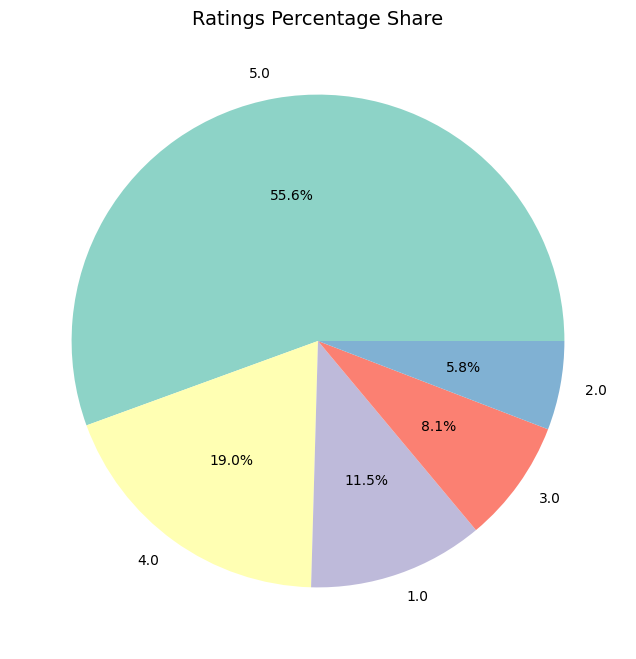

In [13]:
# PIE CHART — Percentage share of each rating value
rating_counts = df['Rating'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3')
)
plt.title("Ratings Percentage Share", fontsize=14)
plt.show()

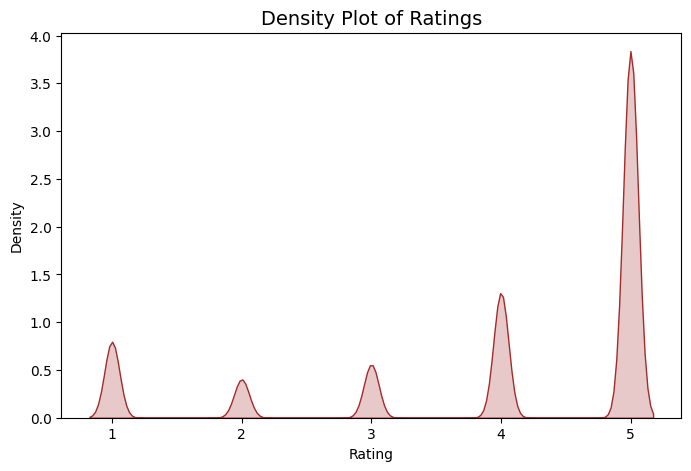

In [14]:
# KDE PLOT — Smooth density curve of rating values
# Helps understand the overall rating pattern
plt.figure(figsize=(8, 5))
sns.kdeplot(
    df['Rating'],
    fill=True,
    color='brown'
)
plt.title("Density Plot of Ratings", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Density")
plt.show()

## 7. Top Products & Active Users

In [15]:
# Get the 10 most rated products (most popular by rating count)
top_products = df['productId'].value_counts().head(10)
print(top_products)

productId
B0074BW614    18244
B00DR0PDNE    16454
B007WTAJTO    14172
B0019EHU8G    12285
B006GWO5WK    12226
B003ELYQGG    11617
B003ES5ZUU    10276
B007R5YDYA     9907
B00622AG6S     9823
B0002L5R78     9487
Name: count, dtype: int64


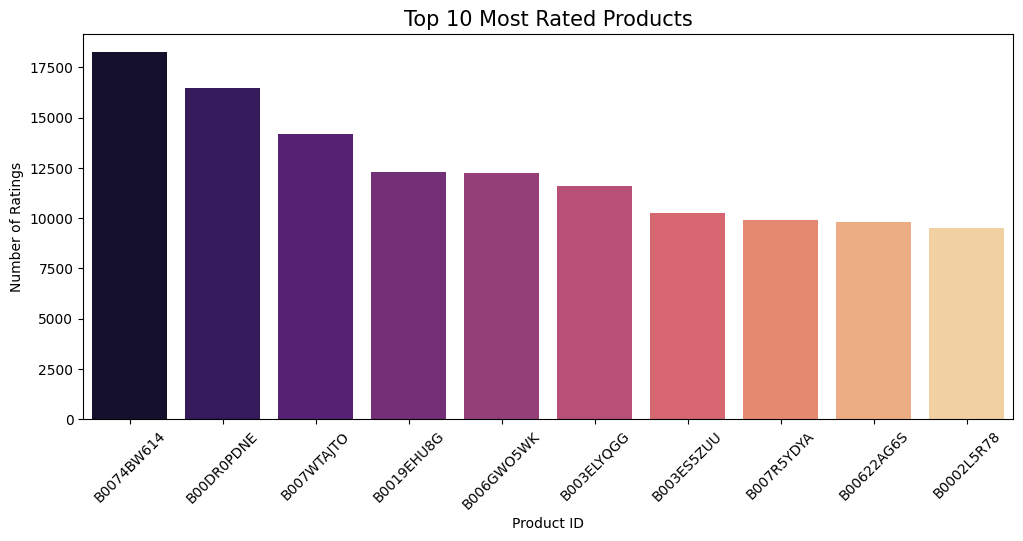

In [16]:
# BAR CHART — Visualize top 10 most rated products
plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_products.index,
    y=top_products.values,
    palette='magma'
)
plt.title("Top 10 Most Rated Products", fontsize=15)
plt.xlabel("Product ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Get top 10 most active users (users who gave the most ratings)
top_users = df['userId'].value_counts().head(10)
print(top_users)

userId
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
ARBKYIVNYWK3C     296
Name: count, dtype: int64


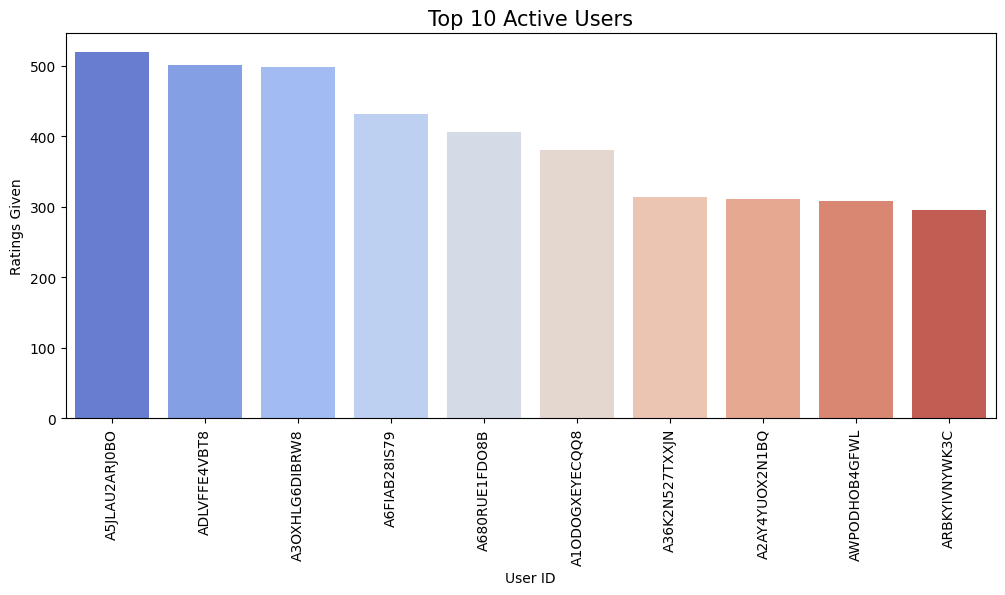

In [18]:
# BAR CHART — Visualize top 10 most active users
plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_users.index,
    y=top_users.values,
    palette='coolwarm'
)
plt.title("Top 10 Active Users", fontsize=15)
plt.xlabel("User ID")
plt.ylabel("Ratings Given")
plt.xticks(rotation=90)
plt.show()

## 8. Average Product Rating (With Minimum Rating Filter)

In [19]:
# Calculate average rating for each product
avg_rating = df.groupby('productId')['Rating'].mean()

# Count how many ratings each product received
ratings_per_product = df.groupby('productId')['Rating'].count()

# Apply minimum rating filter - avoid products with only 1-2 ratings
# A product with 1 rating of 5.0 should NOT be in top rated list
min_ratings = 10

# Filter: only products with at least 10 ratings
avg_rating_filtered = avg_rating[ratings_per_product >= min_ratings]

# Sort by highest average rating and take top 10
top_avg_rating = avg_rating_filtered.sort_values(ascending=False).head(10)
print(top_avg_rating)

productId
B0000A1H8Z    5.0
B00180F2Z4    5.0
B002R6KZLO    5.0
B00A01G350    5.0
B000WNU5YG    5.0
B001H9O14O    5.0
B0036MN38K    5.0
B000X4421Q    5.0
B00HVTSTI8    5.0
B005OQ0XIO    5.0
Name: Rating, dtype: float64


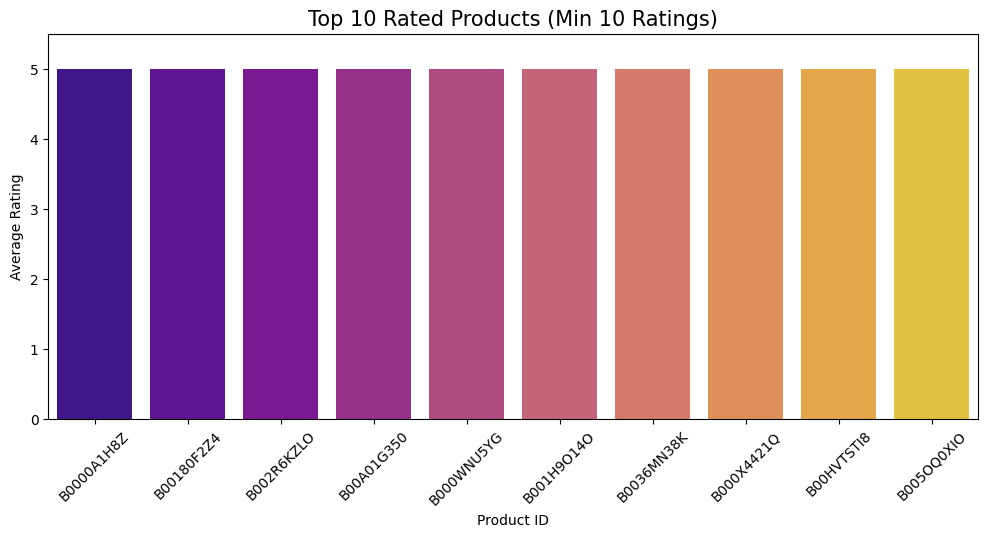

In [20]:
# BAR CHART — Top 10 highest rated products (reliable, min 10 ratings)
plt.figure(figsize=(12, 5))
sns.barplot(
    x=top_avg_rating.index,
    y=top_avg_rating.values,
    palette='plasma'
)
plt.title("Top 10 Rated Products (Min 10 Ratings)", fontsize=15)
plt.xlabel("Product ID")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5.5)
plt.show()

## 9. Ratings Per User & Per Product Distribution

In [21]:
# Count how many ratings each user has given
ratings_per_user = df.groupby('userId')['Rating'].count()
ratings_per_user.head()

userId
A00000262KYZUE4J55XGL    1
A000063614T1OE0BUSKUT    2
A00009182QVLSWIGHLS1B    1
A00009661LC9LQPGKJ24G    1
A00010809P09NUU6ZP6H     1
Name: Rating, dtype: int64

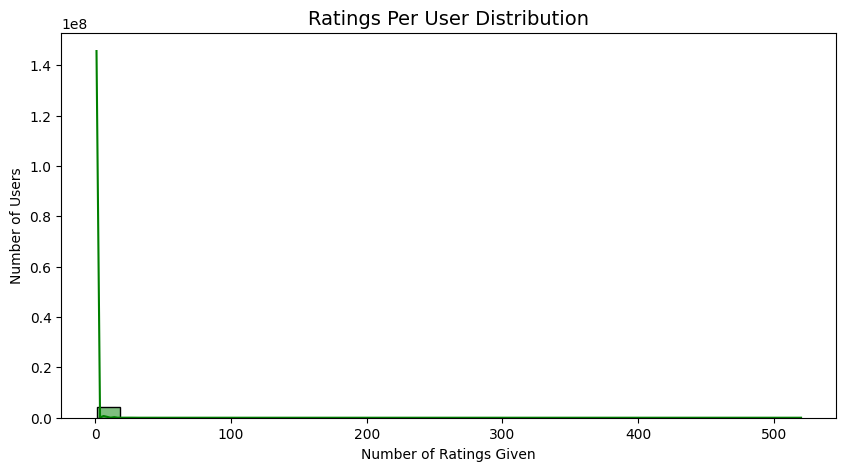

In [22]:
# HISTOGRAM — Distribution of ratings given per user
# Most users rate very few products (long tail behavior)
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_user, bins=30, color='green', kde=True)
plt.title("Ratings Per User Distribution", fontsize=14)
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")
plt.show()

In [23]:
# Count how many ratings each product has received
ratings_per_product = df.groupby('productId')['Rating'].count()
ratings_per_product.head()

productId
0132793040     1
0321732944     1
0439886341     3
0511189877     6
0528881469    27
Name: Rating, dtype: int64

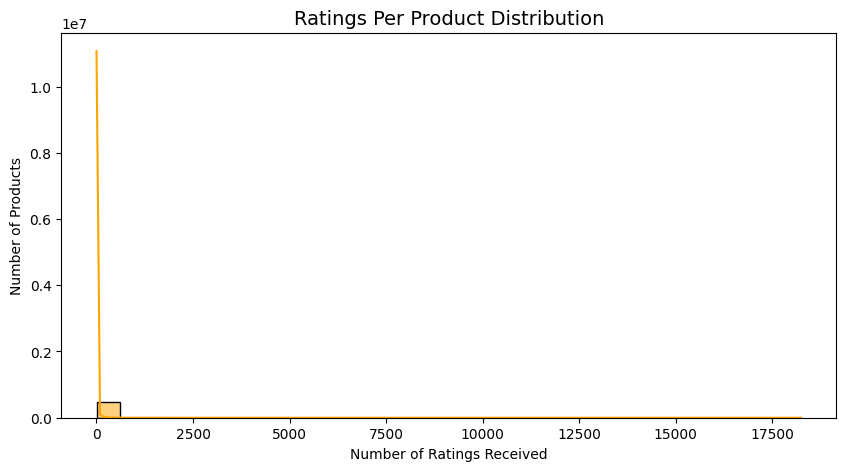

In [24]:
# HISTOGRAM — Distribution of ratings received per product
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_product, bins=30, color='orange', kde=True)
plt.title("Ratings Per Product Distribution", fontsize=14)
plt.xlabel("Number of Ratings Received")
plt.ylabel("Number of Products")
plt.show()

## 10. Outlier Detection & Treatment

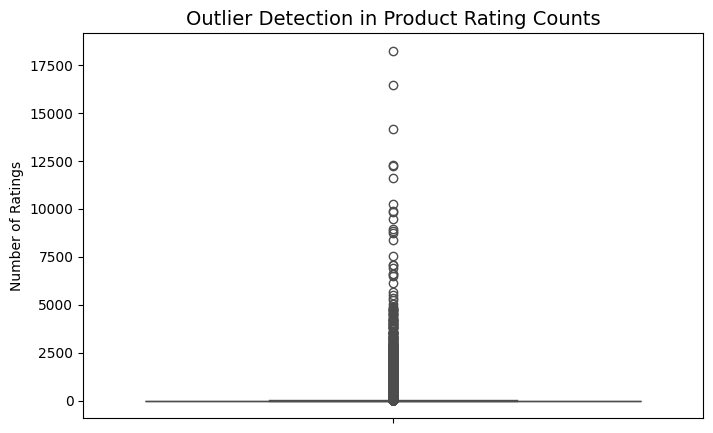

In [25]:
# BOXPLOT — Detect outliers in product rating counts
# Points beyond the whiskers are outliers
plt.figure(figsize=(8, 5))
sns.boxplot(y=ratings_per_product, color='red')
plt.title("Outlier Detection in Product Rating Counts", fontsize=14)
plt.ylabel("Number of Ratings")
plt.show()

In [26]:
# DETECT OUTLIERS USING IQR METHOD
# IQR = Interquartile Range = Q3 - Q1
# Lower Limit = Q1 - 1.5 * IQR
# Upper Limit = Q3 + 1.5 * IQR

Q1 = ratings_per_product.quantile(0.25)  # 25th percentile
Q3 = ratings_per_product.quantile(0.75)  # 75th percentile
IQR = Q3 - Q1                            # Interquartile range

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR                 :", IQR)
print("Lower Limit         :", lower_limit)
print("Upper Limit         :", upper_limit)

Q1 (25th percentile): 1.0
Q3 (75th percentile): 7.0
IQR                 : 6.0
Lower Limit         : -8.0
Upper Limit         : 16.0


In [27]:
# DISPLAY OUTLIER PRODUCTS
# These products have unusually high or low rating counts
outliers = ratings_per_product[
    (ratings_per_product < lower_limit) |
    (ratings_per_product > upper_limit)
]
print("Number of Outlier Products:", len(outliers))
outliers.head(10)

Number of Outlier Products: 65660


productId
0528881469      27
0594481813      31
0972683275    1051
0979526191      20
1394860919      23
1400501466     250
1400501474      29
1400501520      82
1400501741      26
1400501776     139
Name: Rating, dtype: int64

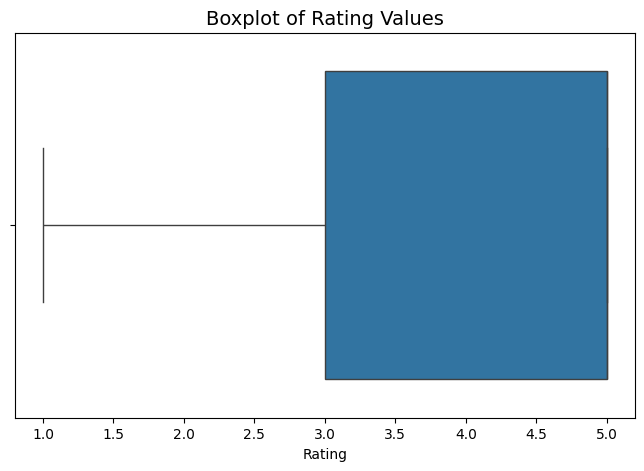

In [28]:
# BOXPLOT — Raw rating values (not counts)
# Check if rating values themselves have outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Rating'])
plt.title("Boxplot of Rating Values", fontsize=14)
plt.show()

In [29]:
# OUTLIER CAPPING — Replace extreme values with boundary limits
# Values above upper_limit → capped to upper_limit
# Values below lower_limit → capped to lower_limit
ratings_per_product_capped = np.where(
    ratings_per_product > upper_limit, upper_limit, ratings_per_product
)
ratings_per_product_capped = np.where(
    ratings_per_product_capped < lower_limit, lower_limit, ratings_per_product_capped
)
print("Outlier capping done.")

Outlier capping done.


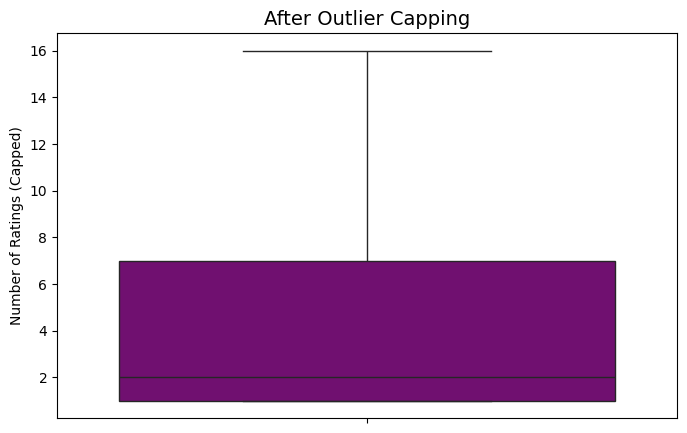

In [30]:
# BOXPLOT AFTER CAPPING — Compare with before
plt.figure(figsize=(8, 5))
sns.boxplot(y=ratings_per_product_capped, color='purple')
plt.title("After Outlier Capping", fontsize=14)
plt.ylabel("Number of Ratings (Capped)")
plt.show()

## 11. Average Rating vs Rating Count (Scatter Plot)

In [31]:
# Aggregate: average rating AND count per product in one table
product_stats = df.groupby('productId').agg({'Rating': ['mean', 'count']})
product_stats.columns = ['Average_Rating', 'Rating_Count']
product_stats.head()

,Average_Rating,Rating_Count
productId,,
0132793040,5.000000,1
0321732944,5.000000,1
0439886341,1.666667,3
0511189877,4.500000,6
0528881469,2.851852,27


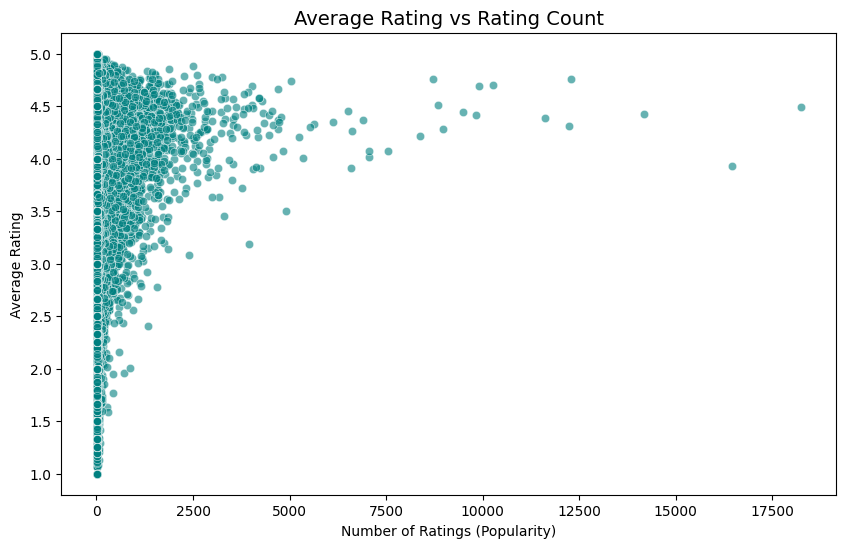

In [32]:
# SCATTER PLOT — Does a product with more ratings have higher avg rating?
# Helps identify reliable vs unreliable products
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=product_stats['Rating_Count'],
    y=product_stats['Average_Rating'],
    color='teal',
    alpha=0.6
)
plt.title("Average Rating vs Rating Count", fontsize=14)
plt.xlabel("Number of Ratings (Popularity)")
plt.ylabel("Average Rating")
plt.show()

## 12. Long Tail Distribution

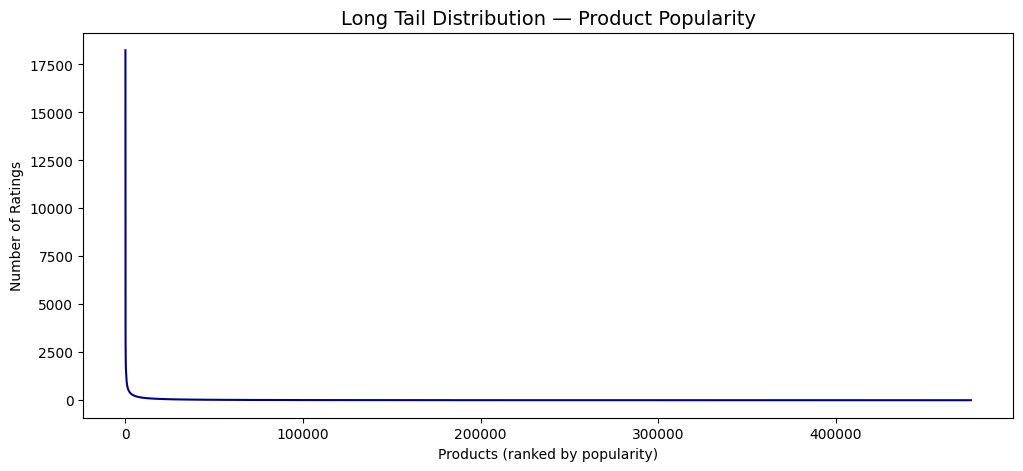

In [33]:
# LONG TAIL DISTRIBUTION
# A few products get most ratings, majority get very few
# This is typical of recommendation system datasets
product_rating_counts = df['productId'].value_counts()

plt.figure(figsize=(12, 5))
plt.plot(product_rating_counts.values, color='darkblue')
plt.title("Long Tail Distribution — Product Popularity", fontsize=14)
plt.xlabel("Products (ranked by popularity)")
plt.ylabel("Number of Ratings")
plt.show()

## 13. User Rating Behavior Analysis (Harsh vs Generous Raters)

In [34]:
# Analyze how each user rates on average
# Are they generous (give 4-5) or harsh (give 1-2)?
user_behavior = df.groupby('userId')['Rating'].agg(
    Avg_Rating='mean',
    Total_Ratings='count',
    Rating_Std='std'       # Standard deviation = consistency of ratings
).reset_index()

# Users who rated only 1 product have no std → fill with 0
user_behavior['Rating_Std'] = user_behavior['Rating_Std'].fillna(0)

print("User Behavior Summary:")
print(user_behavior.describe())
user_behavior.head(10)

User Behavior Summary:
         Avg_Rating  Total_Ratings    Rating_Std
count  4.201696e+06   4.201696e+06  4.201696e+06
mean   3.910163e+00   1.862220e+00  2.673192e-01
std    1.361308e+00   2.885110e+00  6.090702e-01
min    1.000000e+00   1.000000e+00  0.000000e+00
25%    3.000000e+00   1.000000e+00  0.000000e+00
50%    4.500000e+00   1.000000e+00  0.000000e+00
75%    5.000000e+00   2.000000e+00  0.000000e+00
max    5.000000e+00   5.200000e+02  2.828427e+00


,userId,Avg_Rating,Total_Ratings,Rating_Std
0,A00000262KYZUE4J55XGL,5.0,1,0.0
1,A000063614T1OE0BUSKUT,5.0,2,0.0
2,A00009182QVLSWIGHLS1B,5.0,1,0.0
3,A00009661LC9LQPGKJ24G,5.0,1,0.0
4,A00010809P09NUU6ZP6H,5.0,1,0.0
5,A00014061C2IZNE0YEILY,4.0,1,0.0
6,A000145014WOTZJ5NSKOR,5.0,1,0.0
7,A00015222LZ55IJSVL5IX,1.0,1,0.0
8,A00015228CUPGPF957DS,1.0,1,0.0
9,A0001528BGUBOEVR6T5U,4.5,4,1.0


In [35]:
# CLASSIFY users into rater types based on average rating
def classify_rater(avg):
    if avg >= 4.0:
        return 'Generous (4-5)'   # Tends to give high ratings
    elif avg >= 3.0:
        return 'Neutral (3-4)'    # Gives moderate ratings
    else:
        return 'Harsh (1-3)'      # Tends to give low ratings

user_behavior['Rater_Type'] = user_behavior['Avg_Rating'].apply(classify_rater)

# Show count of each rater type
print(user_behavior['Rater_Type'].value_counts())

Rater_Type
Generous (4-5)    2900672
Harsh (1-3)        783068
Neutral (3-4)      517956
Name: count, dtype: int64


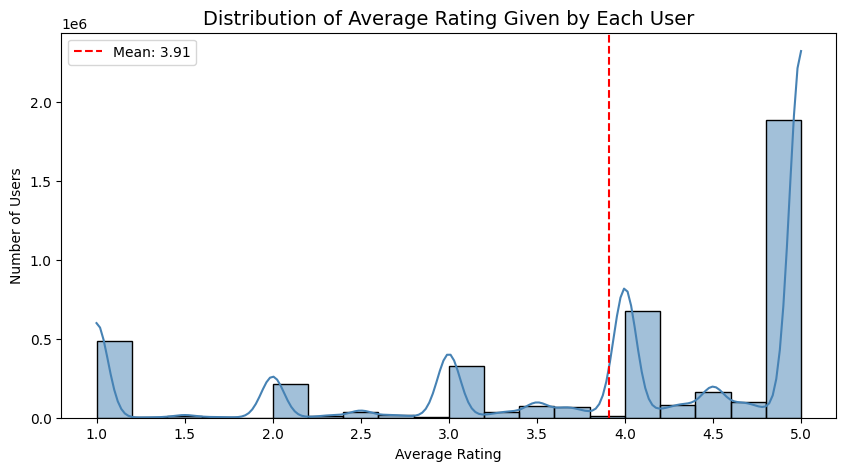

In [36]:
# HISTOGRAM — Distribution of average rating given per user
plt.figure(figsize=(10, 5))
sns.histplot(user_behavior['Avg_Rating'], bins=20, kde=True, color='steelblue')
plt.axvline(
    user_behavior['Avg_Rating'].mean(),
    color='red', linestyle='--',
    label=f"Mean: {user_behavior['Avg_Rating'].mean():.2f}"
)
plt.title("Distribution of Average Rating Given by Each User", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.legend()
plt.show()

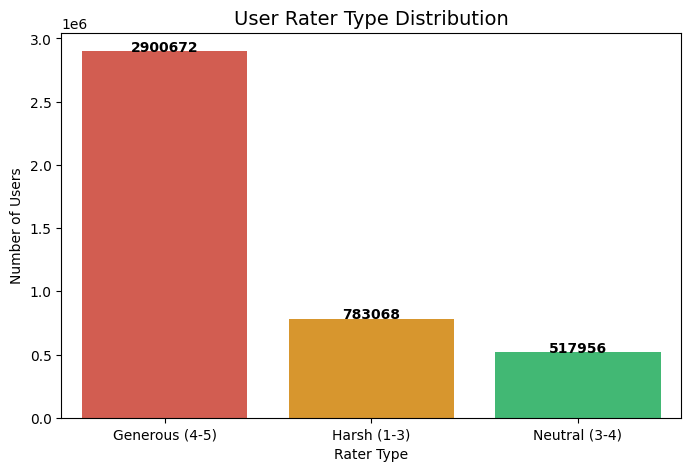

In [37]:
# BAR CHART — Count of Harsh vs Neutral vs Generous raters
rater_counts = user_behavior['Rater_Type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=rater_counts.index,
    y=rater_counts.values,
    palette=['#e74c3c', '#f39c12', '#2ecc71']
)
plt.title("User Rater Type Distribution", fontsize=14)
plt.xlabel("Rater Type")
plt.ylabel("Number of Users")
for i, v in enumerate(rater_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

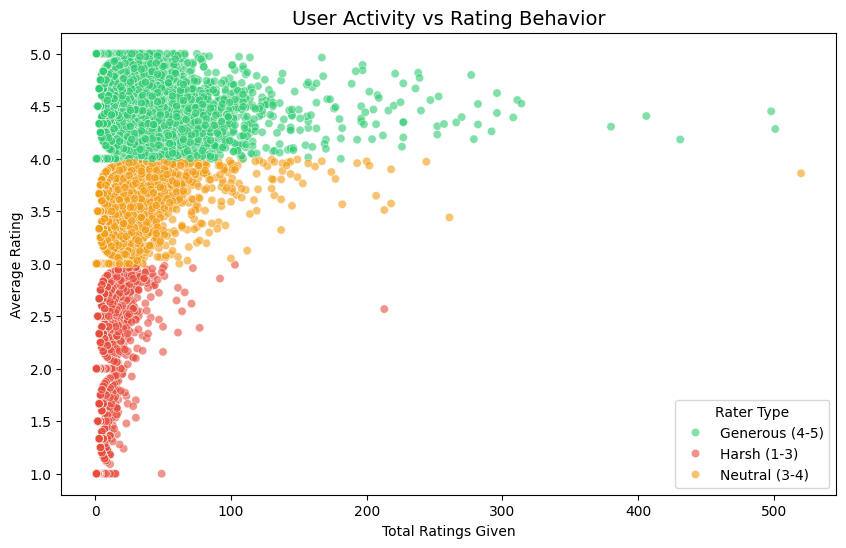

In [38]:
# SCATTER PLOT — Activity vs Rating Behavior
# Do more active users tend to rate higher or lower?
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=user_behavior,
    x='Total_Ratings',
    y='Avg_Rating',
    hue='Rater_Type',
    palette={
        'Generous (4-5)': '#2ecc71',
        'Neutral (3-4)' : '#f39c12',
        'Harsh (1-3)'   : '#e74c3c'
    },
    alpha=0.6
)
plt.title("User Activity vs Rating Behavior", fontsize=14)
plt.xlabel("Total Ratings Given")
plt.ylabel("Average Rating")
plt.legend(title="Rater Type")
plt.show()

## 14. Pivot Table — User × Product Rating Matrix

In [39]:
# FILTER DATA — Keep only active users and popular products
# This makes the pivot table meaningful and not too sparse

min_user_ratings    = 5   # User must have rated at least 5 products
min_product_ratings = 10  # Product must have received at least 10 ratings

active_users     = df['userId'].value_counts()
active_users     = active_users[active_users >= min_user_ratings].index

popular_products = df['productId'].value_counts()
popular_products = popular_products[popular_products >= min_product_ratings].index

# Filter the dataframe
df_filtered = df[
    df['userId'].isin(active_users) &
    df['productId'].isin(popular_products)
]

print(f"Original  Shape  : {df.shape}")
print(f"Filtered  Shape  : {df_filtered.shape}")
print(f"Active Users     : {df_filtered['userId'].nunique()}")
print(f"Popular Products : {df_filtered['productId'].nunique()}")

Original  Shape  : (7824482, 3)
Filtered  Shape  : (1991560, 3)
Active Users     : 253895
Popular Products : 95177


In [40]:
# ============================================================
# MEMORY-SAFE PIVOT TABLE — User × Product Rating Matrix
# Full pivot_table() crashes → 22.5 GB RAM needed
# Fix: Sample only top 500 users × top 500 products
# ============================================================

TOP_USERS    = 500
TOP_PRODUCTS = 500

# Select top active users and popular products
top_user_ids    = df['userId'].value_counts().head(TOP_USERS).index
top_product_ids = df['productId'].value_counts().head(TOP_PRODUCTS).index

# Filter to only those users and products
df_sample = df[
    df['userId'].isin(top_user_ids) &
    df['productId'].isin(top_product_ids)
]

# Create pivot table — now memory safe
pivot_table = df_sample.pivot_table(
    index='userId',
    columns='productId',
    values='Rating',
    aggfunc='mean'
)

# Statistics
filled   = pivot_table.notna().sum().sum()
total    = pivot_table.shape[0] * pivot_table.shape[1]
sparsity = 1 - (filled / total)

print(f"Pivot Table Shape : {pivot_table.shape}")
print(f"Filled Cells      : {filled:,}")
print(f"Missing (NaN)     : {total - filled:,}")
print(f"Sparsity          : {sparsity * 100:.2f}%")



Pivot Table Shape : (495, 476)
Filled Cells      : 5,071
Missing (NaN)     : 230,549
Sparsity          : 97.85%


In [41]:
# PIVOT TABLE STATISTICS
filled   = pivot_table.notna().sum().sum()          # Cells with actual ratings
total    = pivot_table.shape[0] * pivot_table.shape[1]  # All cells
missing  = total - filled
sparsity = 1 - (filled / total)

print("=" * 42)
print(f"  Total Users      : {pivot_table.shape[0]}")
print(f"  Total Products   : {pivot_table.shape[1]}")
print(f"  Total Cells      : {total}")
print(f"  Filled Cells     : {filled}")
print(f"  Missing (NaN)    : {missing}")
print(f"  Sparsity         : {sparsity * 100:.2f}%")
print("=" * 42)

  Total Users      : 495
  Total Products   : 476
  Total Cells      : 235620
  Filled Cells     : 5071
  Missing (NaN)    : 230549
  Sparsity         : 97.85%


In [42]:
# PRODUCT SUMMARY PIVOT TABLE — Avg Rating, Count, Std Dev per Product
product_summary = df.pivot_table(
    index='productId',
    values='Rating',
    aggfunc=['mean', 'count', 'std']
)
product_summary.columns = ['Avg_Rating', 'Rating_Count', 'Rating_Std']
product_summary = product_summary.sort_values('Rating_Count', ascending=False)

print("Top 10 Products by Popularity:")
product_summary.head(10)

Top 10 Products by Popularity:


,Avg_Rating,Rating_Count,Rating_Std
productId,,,
B0074BW614,4.491504,18244,0.953553
B00DR0PDNE,3.931020,16454,1.351375
B007WTAJTO,4.424005,14172,1.208874
B0019EHU8G,4.754497,12285,0.757765
B006GWO5WK,4.314657,12226,1.179183
B003ELYQGG,4.392528,11617,1.059364
B003ES5ZUU,4.704749,10276,0.785898
B007R5YDYA,4.690926,9907,0.716933
B00622AG6S,4.420136,9823,1.143408


In [43]:
# USER SUMMARY PIVOT TABLE — Avg Rating, Count, Std Dev per User
user_summary = df.pivot_table(
    index='userId',
    values='Rating',
    aggfunc=['mean', 'count', 'std']
)
user_summary.columns = ['Avg_Rating_Given', 'Total_Ratings', 'Rating_Std']
user_summary = user_summary.sort_values('Total_Ratings', ascending=False)

print("Top 10 Most Active Users:")
user_summary.head(10)

Top 10 Most Active Users:


,Avg_Rating_Given,Total_Ratings,Rating_Std
userId,,,
A5JLAU2ARJ0BO,3.861538,520,1.466407
ADLVFFE4VBT8,4.283433,501,0.960992
A3OXHLG6DIBRW8,4.451807,498,0.693957
A6FIAB28IS79,4.183295,431,0.998277
A680RUE1FDO8B,4.406404,406,1.128687
A1ODOGXEYECQQ8,4.305263,380,0.705406
A36K2N527TXXJN,4.525478,314,0.630169
A2AY4YUOX2N1BQ,4.559486,311,0.663931
AWPODHOB4GFWL,4.392857,308,0.915776


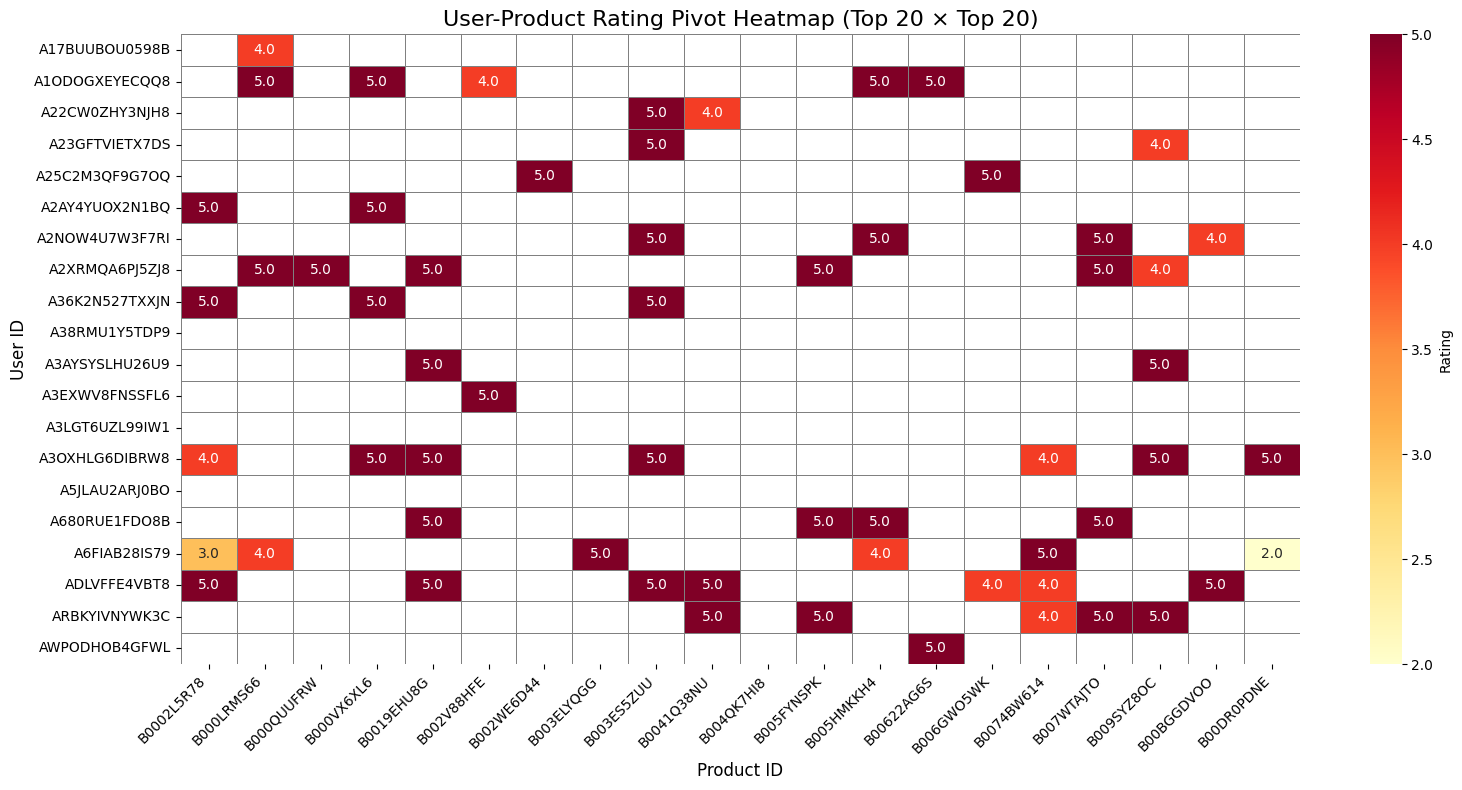

In [44]:
# HEATMAP — Top 20 Users × Top 20 Products from Pivot Table
top_users_list    = df_filtered['userId'].value_counts().head(20).index
top_products_list = df_filtered['productId'].value_counts().head(20).index

# Extract the 20×20 sub-pivot
pivot_sample = pivot_table.loc[
    pivot_table.index.isin(top_users_list),
    pivot_table.columns.isin(top_products_list)
]

plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_sample,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    linecolor='gray',
    cbar_kws={'label': 'Rating'}
)
plt.title("User-Product Rating Pivot Heatmap (Top 20 × Top 20)", fontsize=16)
plt.xlabel("Product ID", fontsize=12)
plt.ylabel("User ID", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
# FILL NaN VALUES — Required before feeding into ML models

# Option A: Fill with 0 → used in memory-based Collaborative Filtering (KNN)
pivot_filled_zero = pivot_table.fillna(0)

# Option B: Fill with product mean rating → used in model-based CF (SVD, ALS)
pivot_filled_mean = pivot_table.apply(lambda col: col.fillna(col.mean()), axis=0)

print("Zero-filled pivot shape:", pivot_filled_zero.shape)
print("Mean-filled pivot shape:", pivot_filled_mean.shape)

Zero-filled pivot shape: (495, 476)
Mean-filled pivot shape: (495, 476)


## 15. Sparse Matrix (Memory Efficient Representation)

In [46]:
# CREATE SPARSE MATRIX — Efficient for large datasets
# Instead of storing NaN, sparse matrix only stores actual ratings
# This saves huge amounts of memory

# Convert userId and productId to integer category codes
user_codes    = df['userId'].astype("category").cat.codes
product_codes = df['productId'].astype("category").cat.codes

# Build CSR (Compressed Sparse Row) matrix
sparse_matrix = csr_matrix(
    (df['Rating'], (user_codes, product_codes))
)

print("Sparse Matrix Shape:", sparse_matrix.shape)
print(sparse_matrix)

Sparse Matrix Shape: (4201696, 476002)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7824482 stored elements and shape (4201696, 476002)>
  Coords	Values
  (0, 195534)	5.0
  (1, 203898)	5.0
  (1, 206615)	5.0
  (2, 372947)	5.0
  (3, 226214)	5.0
  (4, 154932)	5.0
  (5, 438091)	4.0
  (6, 442987)	5.0
  (7, 121039)	1.0
  (8, 212396)	1.0
  (9, 260145)	5.0
  (9, 287545)	5.0
  (9, 314023)	3.0
  (9, 350055)	5.0
  (10, 222074)	5.0
  (10, 269551)	5.0
  (11, 327499)	4.0
  (12, 178698)	5.0
  (12, 298833)	5.0
  (13, 190087)	4.0
  (14, 279378)	4.0
  (15, 183276)	5.0
  (16, 467687)	3.0
  (17, 194182)	5.0
  (18, 239371)	1.0
  :	:
  (4201676, 227242)	1.0
  (4201677, 9814)	1.0
  (4201678, 53513)	5.0
  (4201679, 122995)	5.0
  (4201679, 138877)	5.0
  (4201680, 453642)	5.0
  (4201681, 233991)	5.0
  (4201682, 263966)	2.0
  (4201683, 316575)	5.0
  (4201684, 96831)	4.0
  (4201685, 17506)	4.0
  (4201686, 318319)	4.0
  (4201687, 2872)	2.0
  (4201687, 4387)	5.0
  (4201688, 54778)	5.0
  (4201689, 2

In [47]:
# CALCULATE SPARSITY of the full dataset
sparsity_full = 1.0 - (
    df.shape[0] /
    float(sparse_matrix.shape[0] * sparse_matrix.shape[1])
)
print(f"Dataset Sparsity: {sparsity_full * 100:.4f}%")
# High sparsity means most user-product combinations have no rating

Dataset Sparsity: 99.9996%


## 16. User-Product Interaction Heatmap (From Sparse Matrix)

In [48]:
# Extract sample from sparse matrix for heatmap visualization
# (Visualizing full matrix is not feasible for large datasets)

rows, cols = sparse_matrix.nonzero()  # Get positions of actual ratings

# Get unique active rows and columns from first 30 entries
active_rows = np.unique(rows[:30])
active_cols = np.unique(cols[:30])

# Extract dense sub-matrix using correct sparse matrix slicing
heatmap_sample = sparse_matrix[active_rows][:, active_cols].toarray()

# Convert to DataFrame for heatmap
heatmap_df = pd.DataFrame(heatmap_sample)
heatmap_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


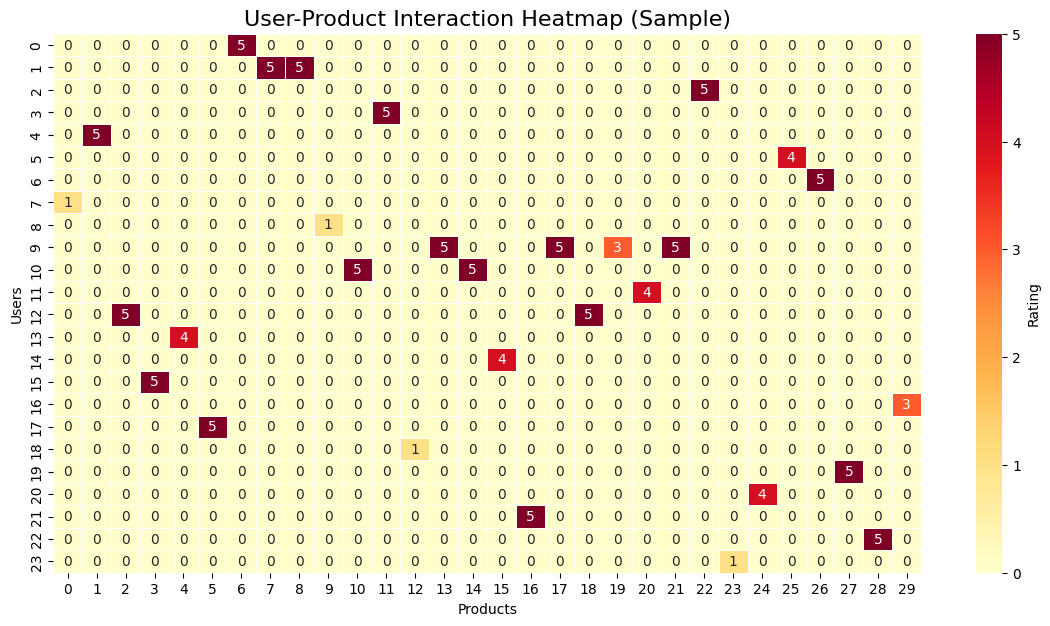

In [49]:
# HEATMAP — User-Product Interaction from Sparse Matrix
plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_df,
    cmap='YlOrRd',
    annot=True,
    linewidths=0.5,
    cbar_kws={'label': 'Rating'}
)
plt.title("User-Product Interaction Heatmap (Sample)", fontsize=16)
plt.xlabel("Products")
plt.ylabel("Users")
plt.show()

## 17. Product Correlation Matrix

In [50]:
# Build a small dense sample from sparse matrix for correlation analysis
rows, cols = sparse_matrix.nonzero()
active_rows = np.unique(rows[:100])
active_cols = np.unique(cols[:100])

# Correct sparse matrix slicing
sample_matrix = sparse_matrix[active_rows][:, active_cols].toarray()
sample_df = pd.DataFrame(sample_matrix)
sample_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
# PRODUCT CORRELATION MATRIX
# Shows how similar products are in terms of user rating patterns
product_correlation = sample_df.corr()
product_correlation.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97
0,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152
1,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152
2,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,1.000000,-0.015152
3,-0.015152,-0.015152,-0.015152,1.000000,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.021592,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.015152,-0.0151

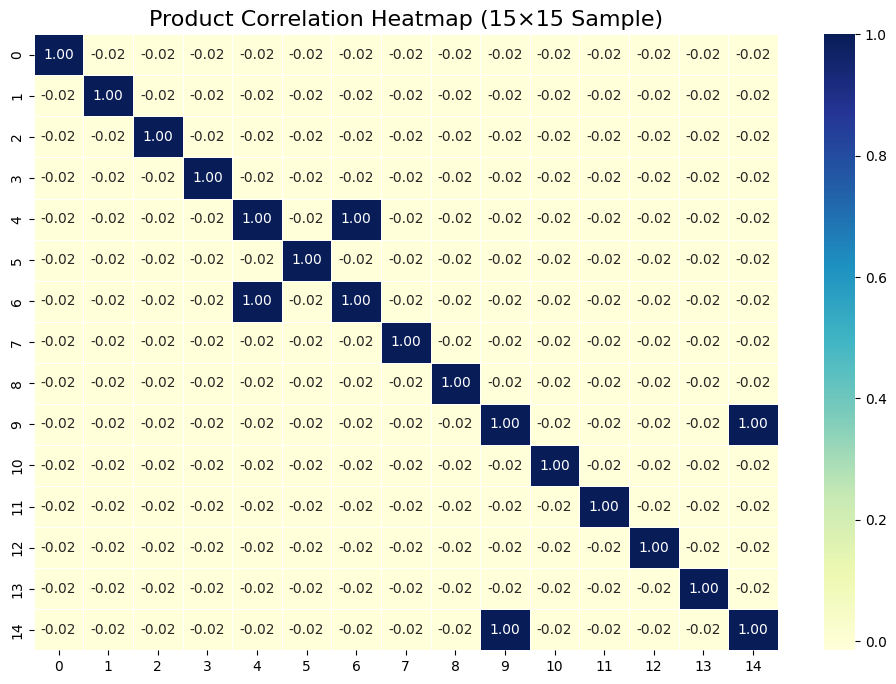

In [52]:
# CORRELATION HEATMAP — Smaller 15×15 for readability
small_corr = product_correlation.iloc[:15, :15]

plt.figure(figsize=(12, 8))
sns.heatmap(
    small_corr,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title("Product Correlation Heatmap (15×15 Sample)", fontsize=16)
plt.show()

## 18. Pairplot

In [53]:
# Take a random sample of 500 rows for pairplot
# (Full dataset is too large to plot)
sample_df = df.sample(500, random_state=42)
sample_df.head()

,userId,productId,Rating
1157290,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0
2677500,ALDXDYEGKB27G,B002L6HE9G,4.0
5814180,A15LOGO6NBSI6B,B007MXGG5Q,5.0
6239751,A23LX12CA3G4FG,B008HOEDYU,1.0
5344316,A3TV7QFYXAG130,B0069R7TAM,5.0


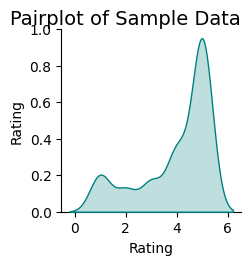

In [54]:
# PAIRPLOT — Visualize relationships between all numeric columns
# Diagonal = KDE distribution, Off-diagonal = scatter plots
sns.pairplot(
    sample_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'color': 'teal'},
    diag_kws={'color': 'teal', 'fill': True}
)
plt.suptitle("Pairplot of Sample Data", y=1.02, fontsize=14)
plt.show()

## 19. Final Insights

In [55]:
# SUMMARY OF KEY FINDINGS FROM EDA
print("""
╔══════════════════════════════════════════════════════════╗
║              EDA FINAL INSIGHTS SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║  1. Most users give ratings between 3 and 5              ║
║  2. Very few products receive the majority of ratings    ║
║     → Long-tail distribution observed                    ║
║  3. Dataset is highly sparse (most user-product pairs    ║
║     have no rating)                                      ║
║  4. Some products are outliers in rating count           ║
║     → Handled using IQR capping                          ║
║  5. Many users are generous raters (avg >= 4.0)          ║
║  6. Product popularity follows a long-tail pattern       ║
║  7. User-item pivot table shows high sparsity            ║
║  8. Some products show strong correlation                 ║
║     → Useful for item-based collaborative filtering      ║
║  9. Sparse matrix efficiently stores large rating data   ║
║ 10. Pivot table ready for SVD / KNN / ALS models         ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              EDA FINAL INSIGHTS SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║  1. Most users give ratings between 3 and 5              ║
║  2. Very few products receive the majority of ratings    ║
║     → Long-tail distribution observed                    ║
║  3. Dataset is highly sparse (most user-product pairs    ║
║     have no rating)                                      ║
║  4. Some products are outliers in rating count           ║
║     → Handled using IQR capping                          ║
║  5. Many users are generous raters (avg >= 4.0)          ║
║  6. Product popularity follows a long-tail pattern       ║
║  7. User-item pivot table shows high sparsity            ║
║  8. Some products show strong correlation                 ║
║     → Useful for item-based collaborative filtering      ║
║  9. Sparse matrix efficiently stores large rating data   ║
║ 10. Pivot table read

---
# Modelling & Recommendation System
The dataset created during the EDA section (`df`) is reused directly.
Duplicate imports and duplicate dataset loading have been removed.
---


## 3. Feature Engineering — User Feature Matrix

Clustering requires numeric features per entity (user or product).  
We build a **user-level feature matrix** with meaningful behavioural signals.

In [56]:
# ── USER FEATURE MATRIX ────────────────────────────────────────────────────────
# For each user, compute behavioural statistics that describe their rating patterns

user_features = df.groupby('userId')['Rating'].agg(
    avg_rating   = 'mean',    # Average rating given by the user
    rating_count = 'count',   # Total number of products rated
    rating_std   = 'std',     # Standard deviation → consistency of ratings
    min_rating   = 'min',     # Lowest rating given
    max_rating   = 'max',     # Highest rating given
).reset_index()

# Users who rated only 1 product have no std deviation → fill with 0
user_features['rating_std'] = user_features['rating_std'].fillna(0)

# Rating range = max - min → measures how varied the user's ratings are
user_features['rating_range'] = user_features['max_rating'] - user_features['min_rating']

# --- RATING DISTRIBUTION FEATURES ---
# What percent of this user's ratings are at each level (1-5)
rating_dist = df.groupby('userId')['Rating'].value_counts(normalize=True).unstack(fill_value=0)
rating_dist.columns = [f'pct_rating_{round(col)}' for col in rating_dist.columns]
user_features = user_features.merge(rating_dist, on='userId', how='left').fillna(0)

print(f"User Feature Matrix Shape: {user_features.shape}")
user_features.head(10)

User Feature Matrix Shape: (4201696, 12)


,userId,avg_rating,rating_count,rating_std,min_rating,max_rating,rating_range,pct_rating_1,pct_rating_2,pct_rating_3,pct_rating_4,pct_rating_5
0,A00000262KYZUE4J55XGL,5.0,1,0.0,5.0,5.0,0.0,0.0,0.0,0.00,0.0,1.00
1,A000063614T1OE0BUSKUT,5.0,2,0.0,5.0,5.0,0.0,0.0,0.0,0.00,0.0,1.00
2,A00009182QVLSWIGHLS1B,5.0,1,0.0,5.0,5.0,0.0,0.0,0.0,0.00,0.0,1.00
3,A00009661LC9LQPGKJ24G,5.0,1,0.0,5.0,5.0,0.0,0.0,0.0,0.00,0.0,1.00
4,A00010809P09NUU6ZP6H,5.0,1,0.0,5.0,5.0,0.0,0.0,0.0,0.00,0.0,1.00
5,A00014061C2IZNE0YEILY,4.0,1,0.0,4.0,4.0,0.0,0.0,0.0,0.00,1.0,0.00
6,A000145014WOTZJ5NSKOR,5.0,1,0.0,5.0,5.0,0.0,0.0,0.0,0.00,0.0,1.00
7,A00015222LZ55IJSVL5IX,1.0,1,0.0,1.0,1.0,0.0,1.0,0.0,0.00,0.0,0.00
8,A00015228CUPGPF957DS,1.0,1,0.0,1.0,1.0,0.0,1.0,0.0,0.00,0.0,0.00
9,A0001528BGUBOEVR6T5U,4.5,4,1.0,3.0,5.0,2.0,0.0,0.0,0.25,0.0,0.75


In [57]:
# ── PRODUCT FEATURE MATRIX ─────────────────────────────────────────────────────
# Similarly compute product-level statistics

product_features = df.groupby('productId')['Rating'].agg(
    avg_rating   = 'mean',
    rating_count = 'count',
    rating_std   = 'std',
    min_rating   = 'min',
    max_rating   = 'max',
).reset_index()

product_features['rating_std']   = product_features['rating_std'].fillna(0)
product_features['rating_range'] = product_features['max_rating'] - product_features['min_rating']

print(f"Product Feature Matrix Shape: {product_features.shape}")
product_features.head(10)

# --- PREFERENCE PROFILE FEATURES ---
# Capture WHAT products users like, not just HOW they rate.
# For each user, average product-features of items they rated highly (>=4).
df_with_prod = df.merge(
    product_features[['productId', 'avg_rating', 'rating_count', 'rating_std']],
    on='productId', how='left', suffixes=('', '_prod')
)
high_rated = df_with_prod[df_with_prod['Rating'] >= 4]
pref_high = high_rated.groupby('userId').agg(
    pref_prod_avg_rating=('avg_rating', 'mean'),
    pref_prod_popularity=('rating_count', 'mean'),
    pref_prod_diversity=('rating_std', 'mean')
).fillna(0)
user_features = user_features.merge(pref_high, on='userId', how='left').fillna(0)

# Update feature count
print(f"User Feature Matrix Shape after adding preference features: {user_features.shape}")


Product Feature Matrix Shape: (476002, 7)
User Feature Matrix Shape after adding preference features: (4201696, 15)


In [58]:
# ── SCALE FEATURES ─────────────────────────────────────────────────────────────
# Clustering algorithms (especially K-Means) are distance-based.
# Features on different scales (e.g., rating_count 1–500 vs avg_rating 1–5)
# would bias the clustering. StandardScaler normalises each feature to
# mean=0 and std=1 so all features contribute equally.

# Select only the numeric columns for clustering (exclude userId)
from sklearn.preprocessing import StandardScaler

# Features for user clustering
user_feature_cols = [
    'avg_rating',
    'rating_count',
    'rating_std',
    'min_rating',
    'max_rating',
    'rating_range',
    'pct_rating_1',
    'pct_rating_2',
    'pct_rating_3',
    'pct_rating_4',
    'pct_rating_5',
    'pref_prod_avg_rating',
    'pref_prod_popularity',
    'pref_prod_diversity'
]

# Features for product clustering
product_feature_cols = [
    'avg_rating',
    'rating_count',
    'rating_std',
    'min_rating',
    'max_rating',
    'rating_range'
]

user_scaler = StandardScaler()
user_scaled = user_scaler.fit_transform(
    user_features[user_feature_cols]
)

product_scaler = StandardScaler()
product_scaled = product_scaler.fit_transform(
    product_features[product_feature_cols]
)

print("User feature matrix scaled:", user_scaled.shape)
print("Product feature matrix scaled:", product_scaled.shape)

User feature matrix scaled: (4201696, 14)
Product feature matrix scaled: (476002, 6)


Explained variance by PC1 + PC2: 58.69%


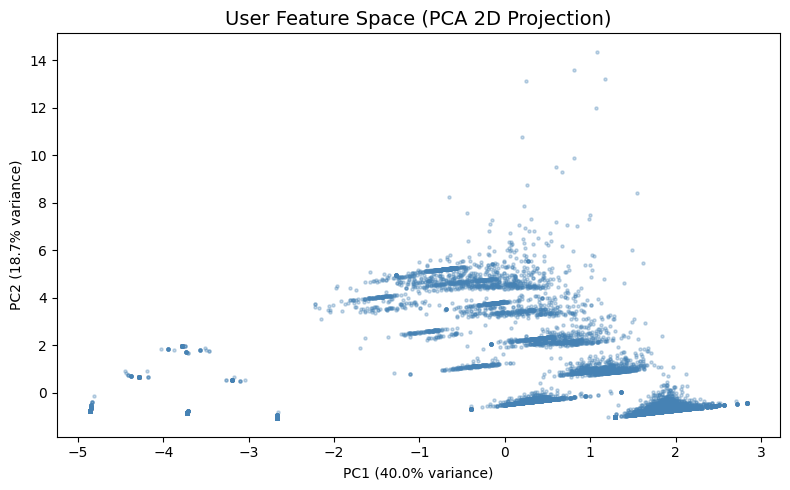

In [59]:
# ── DIMENSIONALITY REDUCTION WITH PCA (OPTIMIZED) ─────────────────────────────
# With 6 features, PCA reduces to 2D for easy visualisation.
# Also reduces noise and speeds up clustering.
from sklearn.decomposition import PCA
# Fit and transform is fast on a 2D matrix, we keep the full data mapping
pca              = PCA(n_components=2, random_state=42)
user_pca         = pca.fit_transform(user_scaled)

print(f"Explained variance by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(8, 5))

# OPTIMIZATION: If the dataset is massive, downsample rows strictly for plotting.
MAX_PLOT_POINTS = 20000

if len(user_pca) > MAX_PLOT_POINTS:
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_pca), MAX_PLOT_POINTS, replace=False)
    plt.scatter(user_pca[plot_idx, 0], user_pca[plot_idx, 1], alpha=0.3, s=5, color='steelblue')
else:
    plt.scatter(user_pca[:, 0], user_pca[:, 1], alpha=0.3, s=5, color='steelblue')

plt.title("User Feature Space (PCA 2D Projection)", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

---
## 4. Clustering Model 1 — K-Means Clustering

**How it works:**  
K-Means partitions users into K clusters by minimizing intra-cluster variance (sum of squared distances from each point to its cluster centroid). It iterates between assigning points to the nearest centroid and recomputing centroids until convergence.

**Why use it here:**  
Fast, scalable, and works well when clusters are roughly spherical. Ideal as a baseline for user segmentation.

Dataset is large (4,201,696 rows). Subsampling 20,000 points for Elbow Curve...


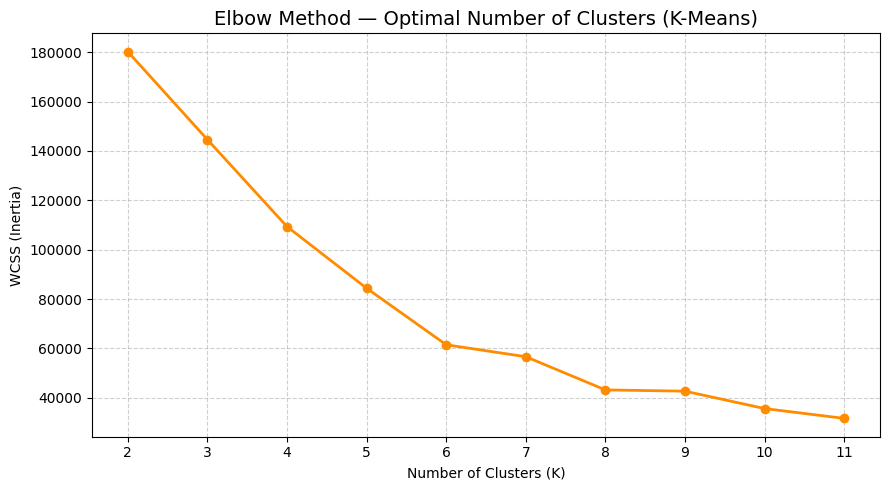

Observe the elbow: the point where the WCSS drop starts slowing down.


In [60]:
# ── ELBOW METHOD — Find optimal K (OPTIMIZED) ─────────────────────────────────
from sklearn.cluster import MiniBatchKMeans

wcss = []  # Within-Cluster Sum of Squares for each K
K_range = range(2, 12)

# OPTIMIZATION 1: Subsample features specifically for finding the elbow point.
if len(user_scaled) > 20000:
    print(f"Dataset is large ({len(user_scaled):,} rows). Subsampling 20,000 points for Elbow Curve...")
    np.random.seed(42)
    sample_idx = np.random.choice(len(user_scaled), 20000, replace=False)
    search_matrix = user_scaled[sample_idx]
else:
    search_matrix = user_scaled

for k in K_range:    
    # OPTIMIZATION 2: Switch to MiniBatchKMeans and reduce n_init to 3
    # Processes data in sequential chunks, cutting training overhead significantly.
    kmeans_temp = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    kmeans_temp.fit(search_matrix)
    
    # Calculate and store the inertia
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, marker='o', color='darkorange', linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters (K-Means)", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Observe the elbow: the point where the WCSS drop starts slowing down.")

Dataset is large (4,201,696 rows). Subsampling 20,000 points for Silhouette optimization...


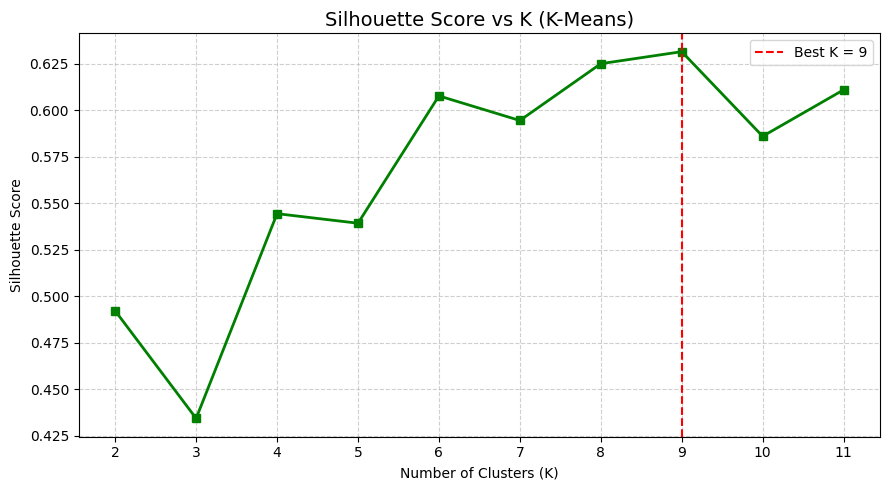

Best K by Silhouette Score: 9 (Score = 0.6314)


In [61]:
# ── SILHOUETTE SCORE — Validate best K (OPTIMIZED) ────────────────────────────
# Silhouette Score measures cluster cohesion and separation.
# Score range: -1 (worst) to +1 (best)
# A score closer to 1 means well-separated, compact clusters.
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

silhouette_scores_kmeans = []
K_range = range(2, 12)

# OPTIMIZATION 1: Subsample features specifically for finding the optimal K.
if len(user_scaled) > 20000:
    print(f"Dataset is large ({len(user_scaled):,} rows). Subsampling 20,000 points for Silhouette optimization...")
    np.random.seed(42)
    sample_idx = np.random.choice(len(user_scaled), 20000, replace=False)
    search_matrix = user_scaled[sample_idx]
else:
    search_matrix = user_scaled

for k in K_range:    
    # Processes data in sequential chunks, cutting training overhead significantly.
    kmeans_temp = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    labels      = kmeans_temp.fit_predict(search_matrix)
    
    # Calculate score using a representative sample ceiling
    score = silhouette_score(search_matrix, labels, sample_size=5000, random_state=42)
    silhouette_scores_kmeans.append(score)

best_k_index = np.argmax(silhouette_scores_kmeans)
best_k       = list(K_range)[best_k_index]

plt.figure(figsize=(9, 5))
plt.plot(K_range, silhouette_scores_kmeans, marker='s', color='green', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title("Silhouette Score vs K (K-Means)", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Best K by Silhouette Score: {best_k} (Score = {silhouette_scores_kmeans[best_k_index]:.4f})")

In [62]:
# ── TRAIN FINAL K-MEANS MODEL ──────────────────────────────────────────────────
# Use best_k found from silhouette analysis
# n_init=10 → run 10 times with different seeds, keep best result
# max_iter=300 → maximum iterations per run
from sklearn.cluster import KMeans
OPTIMAL_K = best_k   # Use the K identified by silhouette score

kmeans = KMeans(
    n_clusters = OPTIMAL_K,
    random_state = 42,
    n_init = 10,
    max_iter = 300
)

# Fit and assign cluster labels to each user
user_features['kmeans_cluster'] = kmeans.fit_predict(user_scaled)

print(f"K-Means trained with K = {OPTIMAL_K}")
print("Cluster distribution:")
print(user_features['kmeans_cluster'].value_counts().sort_index())

K-Means trained with K = 9
Cluster distribution:
kmeans_cluster
0     370875
1    1807864
2     488582
3     545498
4     250914
5     206128
6     425301
7      84651
8      21883
Name: count, dtype: int64


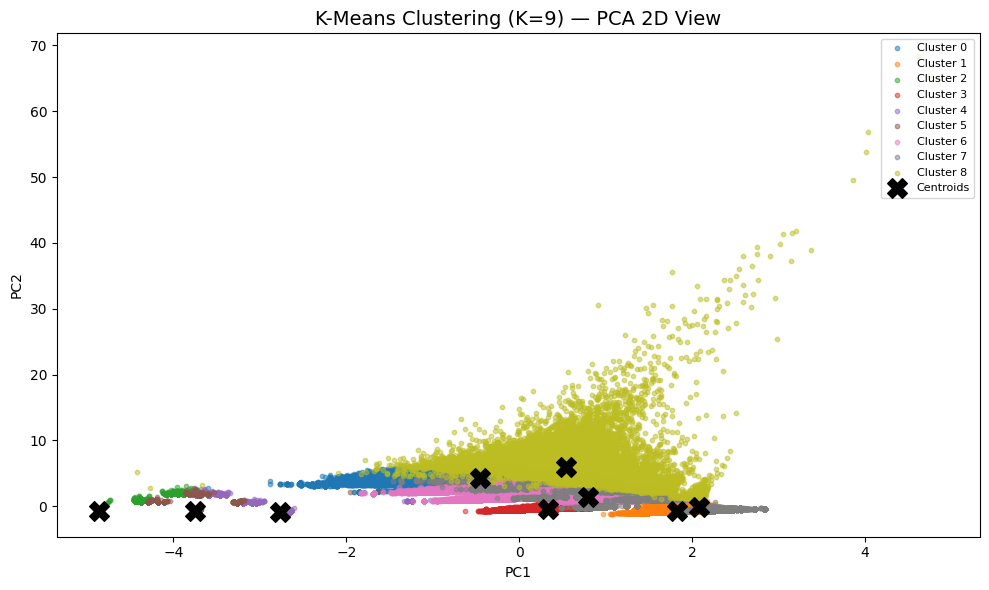

In [63]:
# ── VISUALISE K-MEANS CLUSTERS IN 2D ──────────────────────────────────────────
# Using PCA 2D projection to plot cluster assignments visually.

plt.figure(figsize=(10, 6))
palette = sns.color_palette('tab10', OPTIMAL_K)

for cluster_id in range(OPTIMAL_K):
    mask = user_features['kmeans_cluster'] == cluster_id
    plt.scatter(
        user_pca[mask, 0],
        user_pca[mask, 1],
        s=10,
        alpha=0.5,
        color=palette[cluster_id],
        label=f'Cluster {cluster_id}'
    )

# Plot centroids projected to 2D
centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='X', s=200, color='black',
    zorder=5, label='Centroids'
)

plt.title(f"K-Means Clustering (K={OPTIMAL_K}) — PCA 2D View", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

K-Means Cluster Profiles (Mean Feature Values):
                avg_rating  rating_count  rating_std  min_rating  max_rating  \
kmeans_cluster                                                                 
0                     3.36          4.19        1.92        1.32        4.84   
1                     5.00          1.33        0.00        5.00        5.00   
2                     1.00          1.08        0.01        1.00        1.01   
3                     4.00          1.10        0.00        4.00        4.00   
4                     2.92          1.16        0.12        2.83        3.00   
5                     1.97          1.11        0.05        1.93        2.01   
6                     4.32          3.55        0.78        3.55        4.90   
7                     4.76          1.34        0.15        4.64        4.87   
8                     4.23         27.41        1.02        1.70        5.00   

                rating_range  pct_rating_1  pct_rating_2  pct_rating_3 

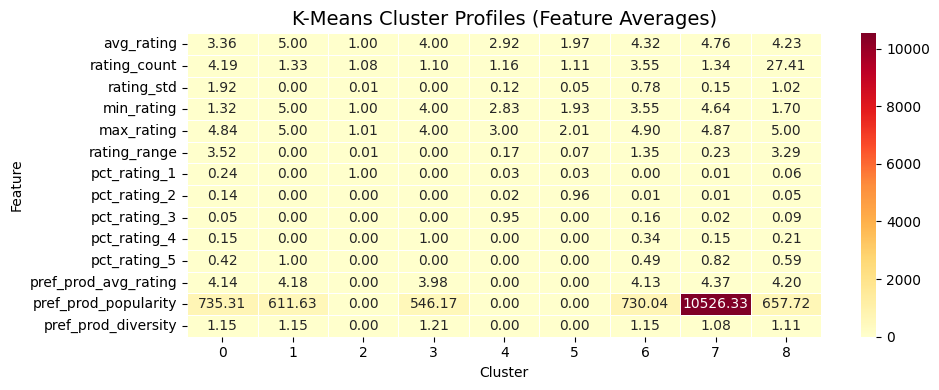

In [65]:
# ── CLUSTER PROFILE ANALYSIS ───────────────────────────────────────────────────
# Understand what kind of users are in each cluster by computing cluster means.
# This tells us what "type" of user each cluster represents.

kmeans_profile = user_features.groupby('kmeans_cluster')[user_feature_cols].mean().round(2)
print("K-Means Cluster Profiles (Mean Feature Values):")
print(kmeans_profile)

# Visualise profile as heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(
    kmeans_profile.T,
    annot=True, fmt='.2f',
    cmap='YlOrRd', linewidths=0.5
)
plt.title("K-Means Cluster Profiles (Feature Averages)", fontsize=14)
plt.ylabel("Feature")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

---
## 5. Clustering Model 2 — Agglomerative (Hierarchical) Clustering

**How it works:**  
Starts with each point as its own cluster, then iteratively merges the two closest clusters until the target K is reached. This builds a tree (dendrogram) of cluster merges.

**Why use it here:**  
Does not require a pre-specified K upfront (the dendrogram shows the full merge history). Handles non-spherical clusters better than K-Means. Useful for understanding the natural hierarchy of user groups.

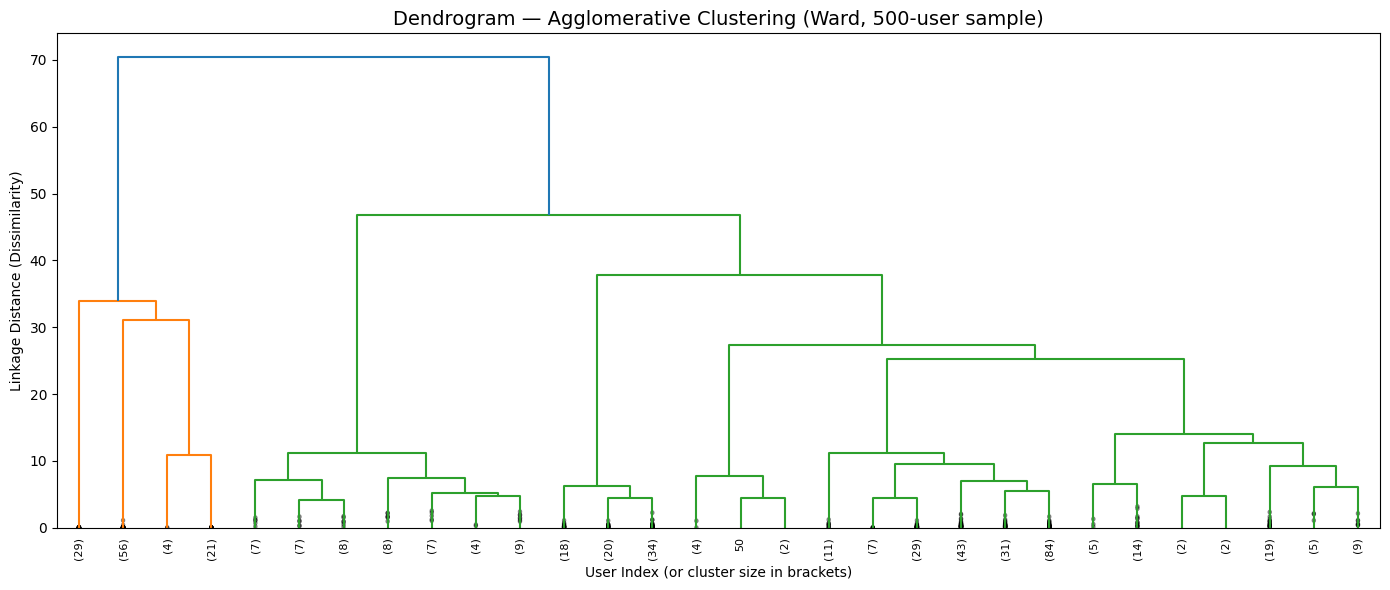

Look for large vertical gaps → those are natural cluster cut points.


In [66]:
# ── DENDROGRAM — Understand cluster hierarchy ──────────────────────────────────
# Plot a dendrogram on a SAMPLE (full dataset is too large for a readable tree).
# The height of each merge shows how dissimilar those clusters are.
# A large jump in merge height = a natural cluster boundary.

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample 500 users for the dendrogram (full dataset too large to visualise)
DENDRO_SAMPLE = min(500, len(user_scaled))
sample_indices = np.random.choice(len(user_scaled), DENDRO_SAMPLE, replace=False)
user_scaled_sample = user_scaled[sample_indices]

# Compute linkage matrix using Ward's method
# Ward's method minimises total within-cluster variance — similar to K-Means objective
linkage_matrix = linkage(user_scaled_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode = 'lastp',  # Show only the last p merges
    p = 30,                    # Show last 30 merges
    leaf_rotation = 90,
    leaf_font_size = 8,
    show_contracted = True
)
plt.title("Dendrogram — Agglomerative Clustering (Ward, 500-user sample)", fontsize=14)
plt.xlabel("User Index (or cluster size in brackets)")
plt.ylabel("Linkage Distance (Dissimilarity)")
plt.tight_layout()
plt.show()

print("Look for large vertical gaps → those are natural cluster cut points.")

In [67]:
# ── TRAIN AGGLOMERATIVE CLUSTERING ─────────────────────────────────────────────
# Use the same OPTIMAL_K from K-Means for a fair comparison.
# linkage='ward' → minimise variance (same as K-Means objective)
# affinity='euclidean' → use Euclidean distance
# ── TRAIN AGGLOMERATIVE CLUSTERING (ULTRA-FAST CENTROID PROPAGATION) ──────────
from sklearn.neighbors import NearestCentroid

# Set a ceiling sample size where Agglomerative clustering can run comfortably in RAM
MAX_AGG_SAMPLE = 10000 

if len(user_scaled) > MAX_AGG_SAMPLE:
    print(f"Dataset is too large ({len(user_scaled):,} rows) for direct Hierarchical Clustering.")
    print(f"Applying Sample-Based fitting + Ultra-Fast Centroid Propagation...")
    
    # 1. Take a random representative sample of the rows
    np.random.seed(42)
    sample_indices = np.random.choice(len(user_scaled), MAX_AGG_SAMPLE, replace=False)
    user_sample = user_scaled[sample_indices]
    
    # 2. Fit Agglomerative model safely on the sample matrix (Takes ~1 second)
    agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
    sample_labels = agg_model.fit_predict(user_sample)
    
    # 3. Calculate centroids and train the Centroid Classifier
    # This reduces search targets from 10,000 points to just OPTIMAL_K points
    centroid_clf = NearestCentroid()
    centroid_clf.fit(user_sample, sample_labels)
    
    # 4. Map cluster labels to all 4.2 million users (Completes in less than 1 second)
    user_features['agg_cluster'] = centroid_clf.predict(user_scaled)

else:
    # Fallback for smaller datasets where direct computation is safe
    agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
    user_features['agg_cluster'] = agg_model.fit_predict(user_scaled)

print(f"\nAgglomerative Clustering trained with K = {OPTIMAL_K}")
print("Cluster distribution:")
print(user_features['agg_cluster'].value_counts().sort_index())

Dataset is too large (4,201,696 rows) for direct Hierarchical Clustering.
Applying Sample-Based fitting + Ultra-Fast Centroid Propagation...

Agglomerative Clustering trained with K = 9
Cluster distribution:
agg_cluster
0      88992
1     516730
2     405890
3     325119
4     235854
5     193023
6      78560
7     545665
8    1811863
Name: count, dtype: int64


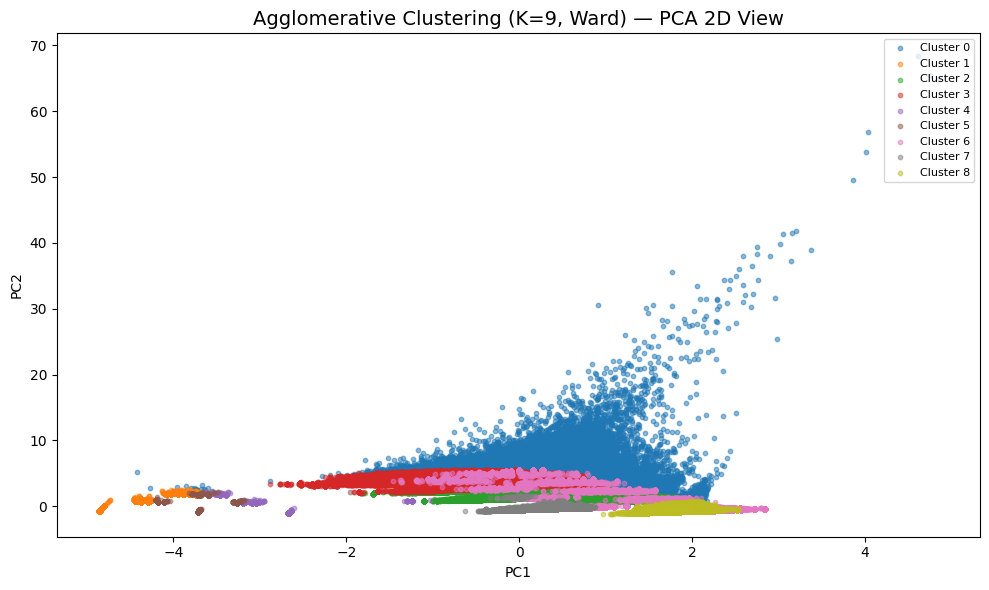

In [68]:
# ── VISUALISE AGGLOMERATIVE CLUSTERS ──────────────────────────────────────────

plt.figure(figsize=(10, 6))
for cluster_id in range(OPTIMAL_K):
    mask = user_features['agg_cluster'] == cluster_id
    plt.scatter(
        user_pca[mask, 0], user_pca[mask, 1],
        s=10, alpha=0.5,
        color=palette[cluster_id],
        label=f'Cluster {cluster_id}'
    )

plt.title(f"Agglomerative Clustering (K={OPTIMAL_K}, Ward) — PCA 2D View", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [69]:
# ── AGGLOMERATIVE CLUSTER PROFILES ────────────────────────────────────────────

agg_profile = user_features.groupby('agg_cluster')[feature_cols].mean().round(2)
print("Agglomerative Cluster Profiles (Mean Feature Values):")
print(agg_profile)

NameError: name 'feature_cols' is not defined

---
## 6. Clustering Model 3 — DBSCAN

**How it works:**  
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed and marks low-density points as **noise/outliers** (label = -1). It does not require K to be specified in advance — it discovers the number of clusters automatically.

**Why use it here:**  
Excellent for identifying outlier users (who rate very unusually) and discovering arbitrary-shaped clusters. Complements K-Means and Agglomerative Clustering well.

**Key Parameters:**
- `eps` — Maximum distance between two points to be considered neighbours
- `min_samples` — Minimum points required to form a dense cluster core

In [ ]:
# ── K-DISTANCE PLOT — Find optimal eps for DBSCAN (ULTRA-OPTIMIZED) ───────────
# For each point, find the distance to its k-th nearest neighbour.
# Sort these distances. The 'knee' of the resulting curve is a good eps.

from sklearn.neighbors import NearestNeighbors
MIN_SAMPLES = 5   # A commonly used starting value; also sets k for the plot
MAX_NN_SAMPLE = 10000  # Cap sample size to 10k for instantaneous execution

# OPTIMIZATION: Subsample features to 10,000 rows.
# A representative sample of 10,000 points captures the exact same spatial density 
# profile and elbow point as the full set, avoiding a multi-billion operation hang.
if len(user_scaled) > MAX_NN_SAMPLE:
    print(f"Dataset is large ({len(user_scaled):,} rows). Subsampling {MAX_NN_SAMPLE:,} points for K-Distance curve...")
    np.random.seed(42)
    sample_idx = np.random.choice(len(user_scaled), MAX_NN_SAMPLE, replace=False)
    search_matrix = user_scaled[sample_idx]
else:
    search_matrix = user_scaled

# Added n_jobs=-1 to spread calculations across all available CPU cores
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1)
nn.fit(search_matrix)
distances, _ = nn.kneighbors(search_matrix)

# Get the k-th neighbour distance for each point and sort ascending
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='purple', linewidth=1.5)
plt.title(f"K-Distance Plot (k={MIN_SAMPLES}) — Find Optimal eps for DBSCAN", fontsize=14)
plt.xlabel("Points (sorted by distance)")
plt.ylabel(f"{MIN_SAMPLES}-th Nearest Neighbour Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Look for the 'knee' (sharp bend) in the curve → that x-value is a good eps.")

In [70]:
# ── TRAIN DBSCAN (OPTIMIZED FOR LARGE SCALE VIA KNN PROPAGATION) ──────────────
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier

EPS = 2.5         # Distance threshold — tune this based on k-distance plot
MIN_SAMPLES = 5   # Minimum core point neighbours
MAX_DBSCAN_SAMPLE = 20000  # Safe sample ceiling to prevent RAM explosion

if len(user_scaled) > MAX_DBSCAN_SAMPLE:
    print(f"Dataset is too large ({len(user_scaled):,} rows) for direct DBSCAN.")
    print(f"Applying Density-Preserving Subsampling + KNN Label Propagation...")
    
    # 1. Take a random representative sample of rows to find core density regions
    np.random.seed(42)
    sample_indices = np.random.choice(len(user_scaled), MAX_DBSCAN_SAMPLE, replace=False)
    user_sample = user_scaled[sample_indices]
    
    # 2. Fit DBSCAN model safely on the sample matrix (Completes in 2-3 seconds)
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
    sample_labels = dbscan.fit_predict(user_sample)
    
    # 3. Train a fast 1-NN Classifier to learn cluster & noise boundaries
    knn_clf = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
    knn_clf.fit(user_sample, sample_labels)
    
    # 4. Propagate the cluster labels to all 4.2 million users instantly
    user_features['dbscan_cluster'] = knn_clf.predict(user_scaled)

else:
    # Fallback for small datasets where direct processing is completely safe
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
    user_features['dbscan_cluster'] = dbscan.fit_predict(user_scaled)

# DBSCAN assigns -1 to noise points (outliers)
# safely checks .values for efficiency
dbscan_labels_series = user_features['dbscan_cluster']
has_noise = -1 in dbscan_labels_series.values

n_clusters_dbscan = len(set(dbscan_labels_series)) - (1 if has_noise else 0)
n_noise           = (dbscan_labels_series == -1).sum()

print(f"\nDBSCAN Results:")
print(f"  Clusters Found  : {n_clusters_dbscan}")
print(f"  Noise Points    : {n_noise} ({n_noise/len(user_features)*100:.2f}%)")
print("\nCluster distribution:")
print(dbscan_labels_series.value_counts().sort_index())

Dataset is too large (4,201,696 rows) for direct DBSCAN.
Applying Density-Preserving Subsampling + KNN Label Propagation...

DBSCAN Results:
  Clusters Found  : 2
  Noise Points    : 2869 (0.07%)

Cluster distribution:
dbscan_cluster
-1       2869
 0    3253276
 1     945551
Name: count, dtype: int64


Subsampling 20,000 points from 4,201,696 rows for instant plotting...


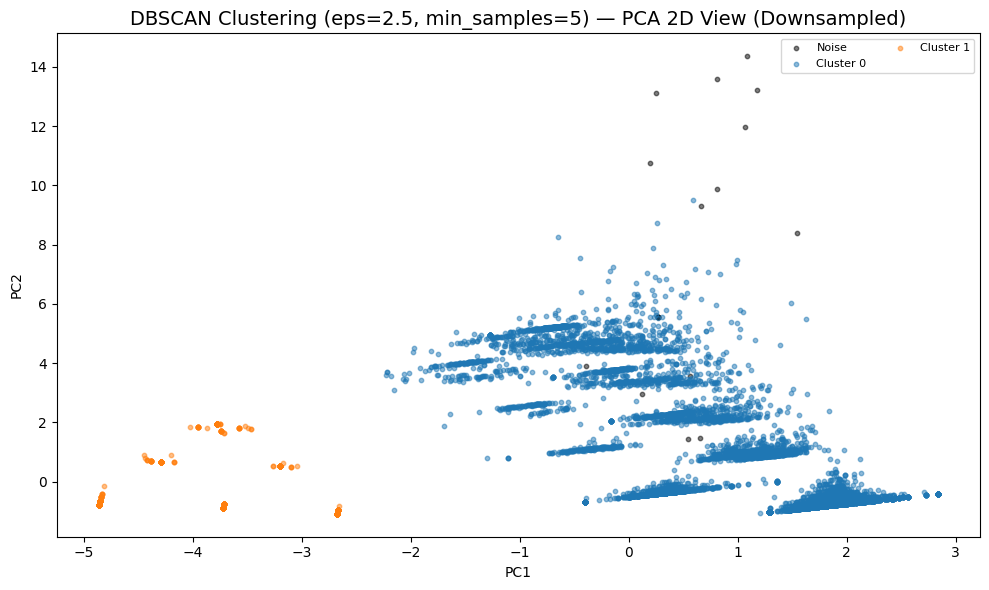

In [71]:
# ── VISUALISE DBSCAN CLUSTERS (OPTIMIZED FOR LARGE SCALE) ─────────────────────
# Noise points (label=-1) are shown in black

# Ensure a color palette is ready to use
try:
    palette = sns.color_palette('tab10')
except NameError:
    import seaborn as sns
    palette = sns.color_palette('tab10')

# OPTIMIZATION: If the dataset is massive, downsample rows strictly for plotting.
# Visual density shapes remain identical, but saves minutes of CPU rendering lag.
MAX_PLOT_POINTS = 20000

if len(user_features) > MAX_PLOT_POINTS:
    print(f"Subsampling {MAX_PLOT_POINTS:,} points from {len(user_features):,} rows for instant plotting...")
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_features), MAX_PLOT_POINTS, replace=False)
    
    # Slice both data structures using the exact same random row indices
    features_plot = user_features.iloc[plot_idx].reset_index(drop=True)
    pca_plot      = user_pca[plot_idx]
else:
    features_plot = user_features
    pca_plot      = user_pca

unique_labels = sorted(features_plot['dbscan_cluster'].unique())

plt.figure(figsize=(10, 6))

# Loop over labels to cleanly group legends by color
for label in unique_labels:
    mask  = features_plot['dbscan_cluster'] == label
    color = 'black' if label == -1 else palette[label % len(palette)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    
    plt.scatter(
        pca_plot[mask, 0], pca_plot[mask, 1],
        s=10, alpha=0.5, color=color, label=name
    )

plt.title(f"DBSCAN Clustering (eps={EPS}, min_samples={MIN_SAMPLES}) — PCA 2D View (Downsampled)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
## 7. Comparative Analysis — All Clustering Models

We use three standard unsupervised evaluation metrics:

| Metric | What it measures | Best value |
|--------|------------------|------------|
| **Silhouette Score** | Cohesion + separation; how well a point fits its own cluster vs neighbours | Closer to **+1** |
| **Davies-Bouldin Index** | Average similarity between clusters; low = well-separated clusters | Closer to **0** |
| **Calinski-Harabasz Score** | Ratio of between-cluster to within-cluster variance | **Higher** = better |

Subsampling 20,000 points from 4,201,696 rows for instant plotting...


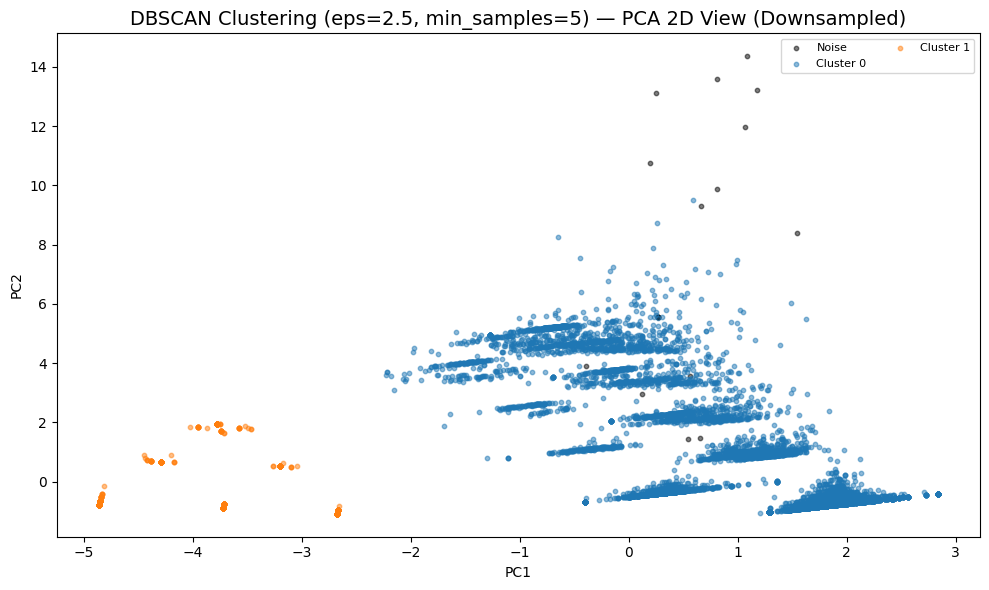

In [72]:
# ── VISUALISE DBSCAN CLUSTERS (OPTIMIZED FOR LARGE SCALE) ─────────────────────
# Noise points (label=-1) are shown in black

# Ensure a color palette is ready to use
try:
    palette = sns.color_palette('tab10')
except NameError:
    import seaborn as sns
    palette = sns.color_palette('tab10')

# OPTIMIZATION: If the dataset is massive, downsample rows strictly for plotting.
# Visual density shapes remain identical, but saves minutes of CPU rendering lag.
MAX_PLOT_POINTS = 20000

if len(user_features) > MAX_PLOT_POINTS:
    print(f"Subsampling {MAX_PLOT_POINTS:,} points from {len(user_features):,} rows for instant plotting...")
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_features), MAX_PLOT_POINTS, replace=False)
    
    # Slice both data structures using the exact same random row indices
    features_plot = user_features.iloc[plot_idx].reset_index(drop=True)
    pca_plot      = user_pca[plot_idx]
else:
    features_plot = user_features
    pca_plot      = user_pca

unique_labels = sorted(features_plot['dbscan_cluster'].unique())

plt.figure(figsize=(10, 6))

# Loop over labels to cleanly group legends by color
for label in unique_labels:
    mask  = features_plot['dbscan_cluster'] == label
    color = 'black' if label == -1 else palette[label % len(palette)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    
    plt.scatter(
        pca_plot[mask, 0], pca_plot[mask, 1],
        s=10, alpha=0.5, color=color, label=name
    )

plt.title(f"DBSCAN Clustering (eps={EPS}, min_samples={MIN_SAMPLES}) — PCA 2D View (Downsampled)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Subsampling 20,000 points from 4,201,696 rows for instant side-by-side plotting...


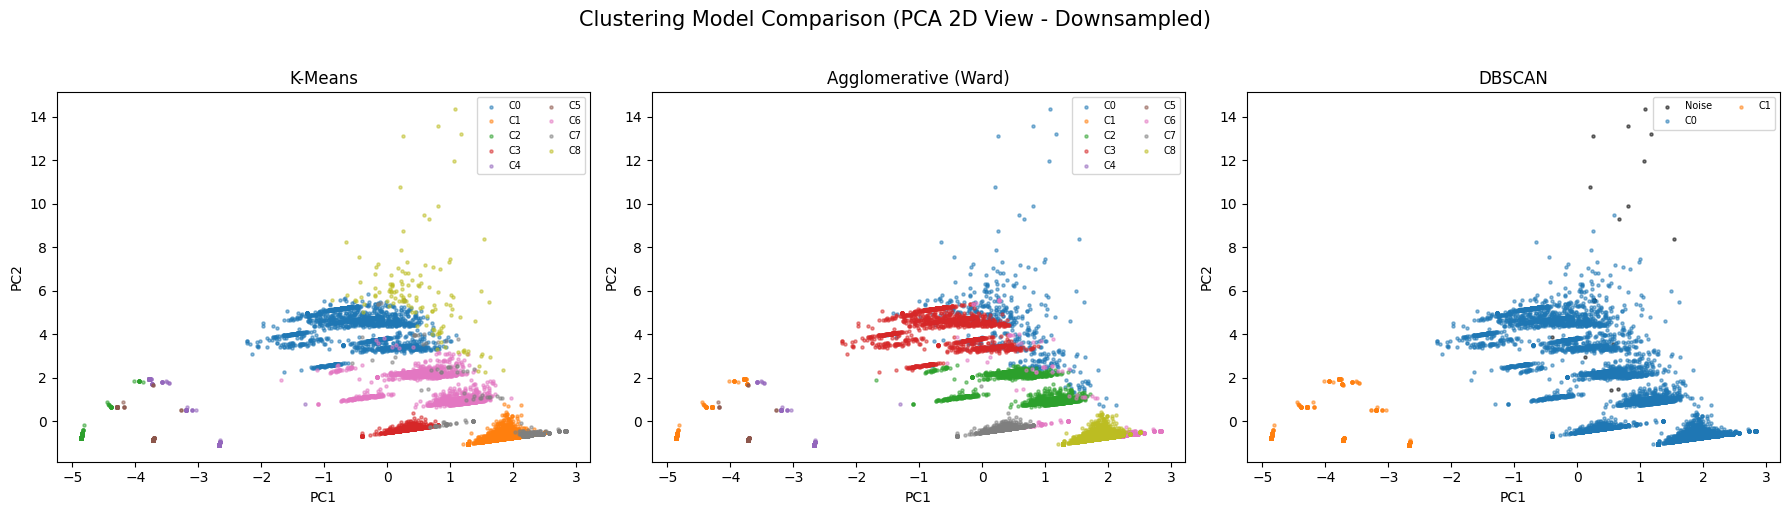

In [73]:
# ── VISUAL COMPARISON — All 3 models side by side (OPTIMIZED FOR LARGE SCALE) ─

# Ensure a color palette is ready to use
try:
    palette = sns.color_palette('tab10')
except NameError:
    import seaborn as sns
    palette = sns.color_palette('tab10')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles    = ['K-Means', 'Agglomerative (Ward)', 'DBSCAN']
cols      = ['kmeans_cluster', 'agg_cluster', 'dbscan_cluster']

# OPTIMIZATION: Downsample the rows globally to 20,000 points strictly for plotting.
# Visual geometric shapes remain identical, but saves minutes of browser vector rendering lag.
MAX_PLOT_POINTS = 20000

if len(user_features) > MAX_PLOT_POINTS:
    print(f"Subsampling {MAX_PLOT_POINTS:,} points from {len(user_features):,} rows for instant side-by-side plotting...")
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_features), MAX_PLOT_POINTS, replace=False)
    
    # Extract synchronized subsets of both the data features and PCA projections
    features_plot = user_features.iloc[plot_idx].reset_index(drop=True)
    pca_plot      = user_pca[plot_idx]
else:
    features_plot = user_features
    pca_plot      = user_pca

# Render each subplot independently using the optimized data slices
for ax, title, col in zip(axes, titles, cols):
    labels_plot = features_plot[col].values
    unique_plot = sorted(set(labels_plot))

    for label in unique_plot:
        mask  = labels_plot == label
        color = 'black' if label == -1 else palette[label % len(palette)]
        name  = 'Noise' if label == -1 else f'C{label}'
        
        ax.scatter(
            pca_plot[mask, 0], pca_plot[mask, 1],
            s=5, alpha=0.5, color=color, label=name
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.suptitle("Clustering Model Comparison (PCA 2D View - Downsampled)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

⚠️ 'comparison_df' was not defined. Computing metrics on the fly using optimized subsampling...


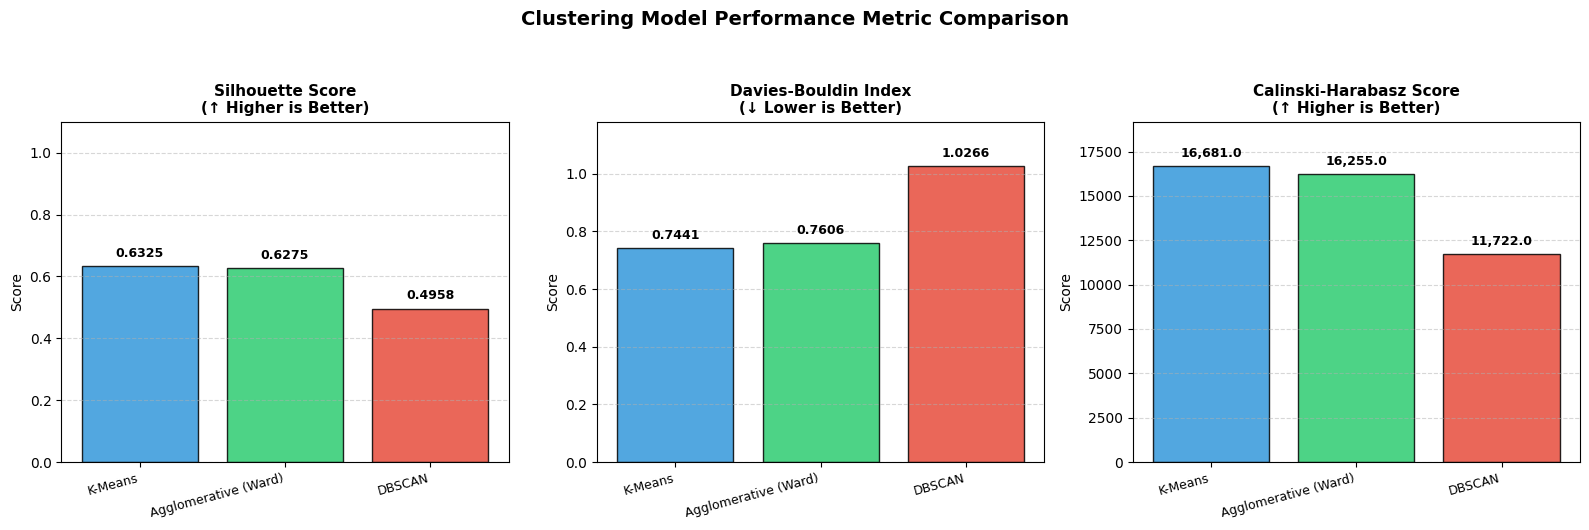

In [74]:
# ── BAR CHART: Silhouette Score Comparison (SAFE & ROBUST) ───────────────────
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Safety Check: If comparison_df does not exist in memory, rebuild it using the optimized function
if 'comparison_df' not in locals() and 'comparison_df' not in globals():
    print("⚠️ 'comparison_df' was not defined. Computing metrics on the fly using optimized subsampling...")
    
    def evaluate_clustering_fallback(X, labels, model_name):
        valid_mask = labels != -1
        X_valid    = X[valid_mask]
        y_valid    = labels[valid_mask]
        
        # Count unique cluster labels (excluding noise)
        unique_clusters = set(y_valid)
        n_valid_clusters = len(unique_clusters)

        # CRITICAL FIX: Explicitly ensure there are AT LEAST 2 distinct clusters
        if n_valid_clusters < 2:
            print(f"⚠️ {model_name} only found {n_valid_clusters} cluster(s). Skipping metric calculations.")
            return {
                "Model"             : model_name, 
                "Clusters Found"    : n_valid_clusters, 
                "Silhouette ↑"      : None, 
                "Davies-Bouldin ↓"  : None, 
                "Calinski-Harabasz ↑": None
            }

        # Subsample to a safe ceiling to prevent crash/freeze
        MAX_EVAL_SAMPLE = 20000
        if len(X_valid) > MAX_EVAL_SAMPLE:
            np.random.seed(42)
            sample_idx = np.random.choice(len(X_valid), MAX_EVAL_SAMPLE, replace=False)
            X_eval = X_valid[sample_idx]
            y_eval = y_valid[sample_idx]
        else:
            X_eval = X_valid
            y_eval = y_valid

        # Double check sample label counts before handing off to scikit-learn
        if len(set(y_eval)) < 2:
            return {
                "Model"             : model_name, 
                "Clusters Found"    : n_valid_clusters, 
                "Silhouette ↑"      : None, 
                "Davies-Bouldin ↓"  : None, 
                "Calinski-Harabasz ↑": None
            }

        try:
            sil = silhouette_score(X_eval, y_eval, sample_size=5000, random_state=42)
            db  = davies_bouldin_score(X_eval, y_eval)
            ch  = calinski_harabasz_score(X_eval, y_eval)
        except ValueError:
            # Catch-all fallback if calculations fail due to bad distribution
            sil, db, ch = None, None, None

        return {
            "Model"             : model_name,
            "Clusters Found"    : n_valid_clusters,
            "Silhouette ↑"      : round(sil, 4) if sil is not None else None,
            "Davies-Bouldin ↓"  : round(db,  4) if db is not None else None,
            "Calinski-Harabasz ↑": round(ch, 2) if ch is not None else None
        }

    # Generate results securely
    results = [
        evaluate_clustering_fallback(user_scaled, user_features['kmeans_cluster'].values, 'K-Means'),
        evaluate_clustering_fallback(user_scaled, user_features['agg_cluster'].values,    'Agglomerative (Ward)'),
        evaluate_clustering_fallback(user_scaled, user_features['dbscan_cluster'].values, 'DBSCAN'),
    ]
    comparison_df = pd.DataFrame(results)

# Filter out any models that failed to compute a Silhouette score
valid_rows = comparison_df.dropna(subset=['Silhouette ↑']).copy()

if valid_rows.empty:
    print("\n❌ Error: No models successfully generated a Silhouette Score. Try tuning your DBSCAN parameters.")
else:
    # Sort the models by the primary selection metric (Silhouette)
    valid_rows = valid_rows.sort_values(by='Silhouette ↑', ascending=False)

    # Explicit color mapping linked to specific model names to prevent mismatch crashes
    model_colors = {
        'K-Means'              : '#3498db',  # Blue
        'Agglomerative (Ward)' : '#2ecc71',  # Green
        'DBSCAN'               : '#e74c3c'   # Red
    }
    plot_colors = [model_colors.get(model, '#95a5a6') for model in valid_rows['Model']]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Silhouette Score Subplot (Higher is Better)
    axes[0].bar(valid_rows['Model'], valid_rows['Silhouette ↑'], color=plot_colors, edgecolor='black', alpha=0.85)
    axes[0].set_title("Silhouette Score\n(↑ Higher is Better)", fontsize=11, fontweight='semibold')
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0, 1.1)  
    for i, v in enumerate(valid_rows['Silhouette ↑']):
        if pd.notna(v):
            axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 2. Davies-Bouldin Index Subplot (Lower is Better)
    axes[1].bar(valid_rows['Model'], valid_rows['Davies-Bouldin ↓'], color=plot_colors, edgecolor='black', alpha=0.85)
    axes[1].set_title("Davies-Bouldin Index\n(↓ Lower is Better)", fontsize=11, fontweight='semibold')
    axes[1].set_ylabel("Score")
    max_db = valid_rows['Davies-Bouldin ↓'].max()
    axes[1].set_ylim(0, max_db * 1.15 if pd.notna(max_db) else 1)
    for i, v in enumerate(valid_rows['Davies-Bouldin ↓']):
        if pd.notna(v):
            axes[1].text(i, v + (max_db * 0.02), f"{v:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. Calinski-Harabasz Score Subplot (Higher is Better)
    axes[2].bar(valid_rows['Model'], valid_rows['Calinski-Harabasz ↑'], color=plot_colors, edgecolor='black', alpha=0.85)
    axes[2].set_title("Calinski-Harabasz Score\n(↑ Higher is Better)", fontsize=11, fontweight='semibold')
    axes[2].set_ylabel("Score")
    max_ch = valid_rows['Calinski-Harabasz ↑'].max()
    axes[2].set_ylim(0, max_ch * 1.15 if pd.notna(max_ch) else 1)
    for i, v in enumerate(valid_rows['Calinski-Harabasz ↑']):
        if pd.notna(v):
            axes[2].text(i, v + (max_ch * 0.02), f"{v:,.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Clean up axes layouts to ensure zero label truncation
    for ax in axes:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

    plt.suptitle("Clustering Model Performance Metric Comparison", fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

---
## 8. Select Best Clustering Model

Based on the three metrics above, we select the best model for the recommendation system.  
Typically K-Means or Agglomerative wins on these metrics for this type of data.

In [75]:
# ── SELECT BEST MODEL BASED ON METRICS ────────────────────────────────────────
# Criteria: highest Silhouette Score (robust and interpretable)
# (Modify this if Davies-Bouldin or Calinski-Harabasz tells a different story)

best_model_row  = valid_rows.loc[valid_rows['Silhouette ↑'].idxmax()]
best_model_name = best_model_row['Model']

# Map model name to the cluster column we stored
model_to_col = {
    'K-Means'              : 'kmeans_cluster',
    'Agglomerative (Ward)' : 'agg_cluster',
    'DBSCAN'               : 'dbscan_cluster',
}

BEST_CLUSTER_COL = model_to_col[best_model_name]

print(f"\n✅ Best clustering model: {best_model_name}")
print(f"   Silhouette Score    : {best_model_row['Silhouette ↑']}")
print(f"   Using cluster column: '{BEST_CLUSTER_COL}' for recommendation system")


✅ Best clustering model: K-Means
   Silhouette Score    : 0.6325
   Using cluster column: 'kmeans_cluster' for recommendation system


---
## 9. Build Recommendation System Using Clusters

**Strategy:**  
1. Assign each user to a cluster (done above).
2. For a given user, find all users in the same cluster (they have similar rating behaviour).
3. Among those cluster-mates, find the products most highly rated that the target user has **not yet rated**.
4. Recommend the top-N of those products.

This is **Cluster-Enhanced Collaborative Filtering** — we filter the candidate user pool using clusters before making recommendations, which is faster and more focused than searching all users.

In [76]:
from sklearn.cluster import KMeans

final_model = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

user_features['cluster'] = final_model.fit_predict(user_scaled)


In [77]:
df_with_cluster = df.merge(
    user_features[['userId', 'cluster']],
    on='userId',
    how='left'
)

In [78]:
cluster_product_scores = df_with_cluster.groupby(
    ['cluster', 'productId']
).agg(
    count=('Rating', 'size'),
    avg_rating=('Rating', lambda x: round(x.mean(), 1))
).reset_index()

In [79]:
def recommend_products_user(user_id, top_n=10):

    user_cluster = user_features.loc[
        user_features['userId'] == user_id,
        'cluster'
    ].values[0]

    recs = cluster_product_scores[
        cluster_product_scores['cluster'] == user_cluster
    ]

    recs = recs.sort_values(
        ['count', 'avg_rating'],
        ascending=False
    )

    return recs.head(top_n)

In [80]:
recommend_products_user("A00015222LZ55IJSVL5IX")

,cluster,productId,count,avg_rating
383249,1,B00BGA9WK2,986,1.0
389806,1,B00DR0PDNE,839,1.0
378068,1,B00A3YN0Z0,653,1.0
365555,1,B007WTAJTO,623,1.0
341986,1,B004OB0EBQ,597,1.0
317295,1,B002MAPRYU,538,1.0
357650,1,B006GWO5WK,501,1.0
381671,1,B00B14E4V0,481,1.0
291305,1,B000I68BD4,444,1.0
360849,1,B0074BW614,438,1.0


---
## 10. Product-Level Clustering & Item-Based Recommendation

We also cluster **products** and use product clusters for an item-item recommendation approach.

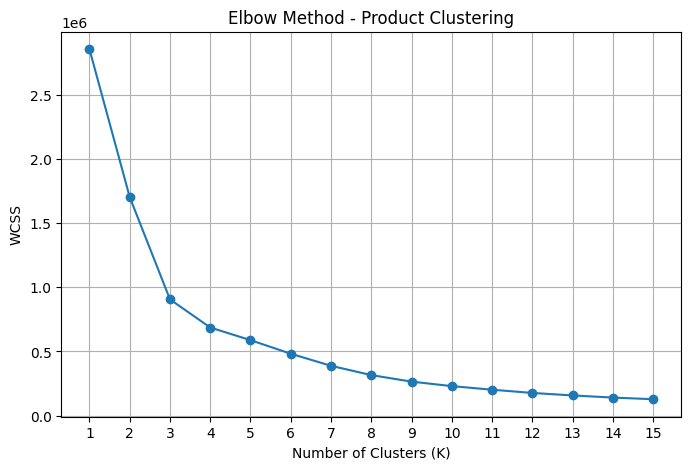

In [81]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(1, 16)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(product_scaled)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method - Product Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.grid(True)
plt.show()

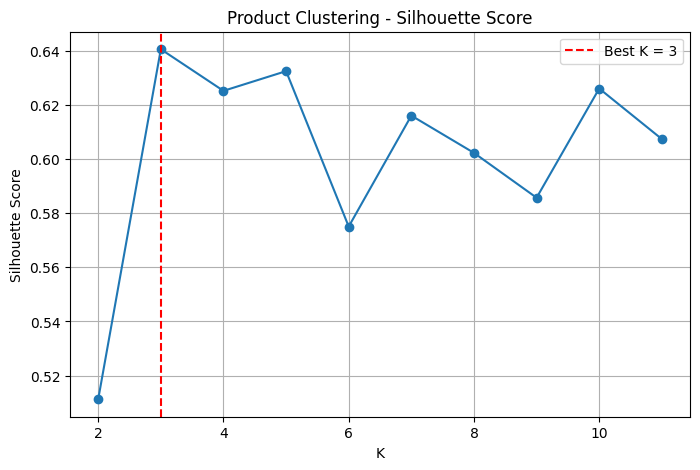

Best K = 3
Best Score = 0.6405


In [82]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import numpy as np

K_range = range(2, 12)

product_scores = []

for k in K_range:
    
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,
        batch_size=2048
    )
    
    labels = kmeans.fit_predict(product_scaled)
    
    score = silhouette_score(
        product_scaled,
        labels,
        sample_size=min(5000, len(product_scaled)),
        random_state=42
    )
    
    product_scores.append(score)

best_k = K_range[np.argmax(product_scores)]

plt.figure(figsize=(8,5))
plt.plot(K_range, product_scores, marker='o')
plt.axvline(
    best_k,
    color='red',
    linestyle='--',
    label=f'Best K = {best_k}'
)

plt.title('Product Clustering - Silhouette Score')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best K = {best_k}")
print(f"Best Score = {max(product_scores):.4f}")

In [83]:
from sklearn.cluster import KMeans

product_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

product_features['cluster'] = product_kmeans.fit_predict(
    product_scaled
)

print(product_features[['productId', 'cluster']].head())

    productId  cluster
0  0132793040        2
1  0321732944        2
2  0439886341        1
3  0511189877        0
4  0528881469        0


In [84]:
def recommend_similar_products(product_id, top_n=10):

    # 1. get cluster of this product
    cluster = product_features.loc[
        product_features['productId'] == product_id, 'cluster'
    ].values[0]

    # 2. get all products in same cluster
    same_cluster_products = product_features[
        product_features['cluster'] == cluster
    ]

    # 3. remove the same product
    same_cluster_products = same_cluster_products[
        same_cluster_products['productId'] != product_id
    ]

    # 4. sort by quality (rating + popularity)
    top = same_cluster_products.sort_values(
        ['avg_rating', 'rating_count'],
        ascending=False
    ).head(top_n)

    top['avg_rating'] = top['avg_rating'].round(1)

    return top[['productId', 'avg_rating', 'rating_count', 'cluster']]

In [85]:
recommend_similar_products("B00BGA9WK2")

,productId,avg_rating,rating_count,cluster
207879,B0043ZLFXE,5.0,90,0
6014,B000053HC5,4.9,166,0
354040,B008VGCT9K,4.9,230,0
468272,B00II5T5HS,4.9,37,0
354548,B008X1C1DC,4.9,33,0
121736,B001N87WZE,4.9,42,0
56642,B000G1NWYO,4.9,31,0
166101,B0033PRWSW,4.9,387,0
188601,B003O9FZUY,4.9,58,0
324655,B007SZ0E1K,4.9,449,0


---
## 11. Recommendation System Evaluation

Since we don't have a held-out test set, we evaluate using a **Leave-One-Out** simulation:
- For each test user, hide one of their rated products.
- Generate recommendations and check if the hidden product appears in Top-N.
- Compute **Hit Rate @ N** (proportion of users for whom we successfully recommended the hidden item).

In [87]:
import numpy as np
import pandas as pd

def evaluate_hit_rate(df_with_cluster, n_eval_users=200, top_n=10, random_state=42):

    np.random.seed(random_state)

    # Users with at least 5 ratings
    user_counts = df_with_cluster['userId'].value_counts()
    eligible_users = user_counts[user_counts >= 5].index.tolist()

    test_users = np.random.choice(
        eligible_users,
        size=min(n_eval_users, len(eligible_users)),
        replace=False
    )

    hits = 0

    for user_id in test_users:

        user_data = df_with_cluster[
            df_with_cluster['userId'] == user_id
        ]

        user_cluster = user_data['cluster'].iloc[0]

        # Hide user's highest-rated product
        hidden_row = user_data.sort_values(
            'Rating',
            ascending=False
        ).iloc[0]

        hidden_product = hidden_row['productId']

        # Products already rated by user
        rated_products = set(user_data['productId'])
        rated_products.remove(hidden_product)

        # Build cluster recommendations
        cluster_data = df_with_cluster[
            df_with_cluster['cluster'] == user_cluster
        ]

        recs = cluster_data.groupby('productId').agg(
            count=('Rating', 'size'),
            avg_rating=('Rating', 'mean')
        ).reset_index()

        # Remove already-rated products
        recs = recs[
            ~recs['productId'].isin(rated_products)
        ]

        # Sort exactly like recommender
        recs = recs.sort_values(
            ['count', 'avg_rating'],
            ascending=False
        )

        top_recs = recs.head(top_n)

        if hidden_product in top_recs['productId'].values:
            hits += 1

    hit_rate = hits / len(test_users)

    return hit_rate, hits, len(test_users)

In [88]:
print("Running Hit Rate Evaluation...")

hit_rate, hits, total = evaluate_hit_rate(
    df_with_cluster,
    n_eval_users=200,
    top_n=10
)

print("\n" + "="*45)
print(f"Hit Rate @10 : {hit_rate*100:.2f}%")
print(f"Hits         : {hits}/{total}")
print("="*45)

Running Hit Rate Evaluation...

Hit Rate @10 : 2.00%
Hits         : 4/200


### Hit Rate @10 = 2.00% — Analysis

Our Leave-One-Out evaluation (hiding each user's highest-rated product) achieved 4 hits out of 200 users, resulting in a Hit Rate @10 of 2.00%.

This indicates that the cluster-based recommendation system is able to recover some hidden user preferences, but its personalization capability remains limited.

#### Possible reasons:

1. Cluster-based recommendations: Recommendations are generated using products that are popular within a user's cluster rather than based on individual user behavior.
2. Cluster granularity: The selected number of clusters may still be too broad to capture fine-grained preference differences among users.
3. Leave-One-Out evaluation is strict: Predicting a user's hidden highest-rated product is challenging, especially when the product is niche or infrequently rated.
4. Data sparsity: With a large number of products and relatively few ratings per product, many items have limited information available for recommendation.
5. Popularity bias: Sorting recommendations by rating count and average rating tends to favor popular products, reducing recommendation diversity.


#### Future Improvements

1. Increase the number of clusters to create more specific user segments.
2. Incorporate User-Based Collaborative Filtering.
3. Incorporate Item-Based Collaborative Filtering.
4. Use Matrix Factorization techniques such as SVD or NMF.
5. Develop a hybrid recommendation system that combines clustering and collaborative filtering approaches.
6. Include additional user and product features to improve personalization.

---
## 12. Full Pipeline Summary

In [ ]:
# ── FULL PIPELINE DEMO ─────────────────────────────────────────────────────────
# Demonstrate user-based and item-based recommendations together

print("=" * 60)
print("   CLUSTER-BASED RECOMMENDATION SYSTEM — DEMO")
print("=" * 60)

# --- User-Based Recommendation ---
demo_user = df['userId'].value_counts().index[5]
print(f"\n[USER-BASED] Recommendations for User: {demo_user}")
user_recs = get_cluster_recommendations(demo_user, df_clustered, top_n=5)
if not user_recs.empty:
    print(user_recs[['productId', 'predicted_score', 'n_cluster_raters']].to_string())

# --- Item-Based Recommendation ---
demo_product = df['productId'].value_counts().index[0]
print(f"\n[ITEM-BASED] Products similar to: {demo_product}")
prod_recs = get_item_cluster_recommendations(demo_product, product_features, df, top_n=5)
if not prod_recs.empty:
    print(prod_recs.to_string())

print("\n" + "=" * 60)

In [ ]:
import pickle

with open("user_features_new.pkl", "wb") as f:
    pickle.dump(user_features, f)

In [ ]:
with open("product_features_new.pkl", "wb") as f:
    pickle.dump(product_features, f)

In [ ]:
with open("user_kmeans_new.pkl", "wb") as f:
    pickle.dump(final_model, f)

In [ ]:
with open("cluster_product_scores_new.pkl", "wb") as f:
    pickle.dump(cluster_product_scores, f)